# TCN Baseline
Temporal Convolutional Network baseline theo pipeline TLSTM, danh gia Accuracy, Macro F1, AUC, QWK.

In [1]:
import os
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler, label_binarize
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc, cohen_kappa_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def detect_kaggle_runtime() -> bool:
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '').strip():
        return True
    return Path('/kaggle/input').exists() and Path('/kaggle/working').exists()

IN_KAGGLE = detect_kaggle_runtime()

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').exists() and (p / 'src').exists():
            return p
    return start

PROJECT_ROOT = Path('/kaggle/working') if IN_KAGGLE else find_project_root(Path.cwd().resolve())
ARTIFACT_DIR = PROJECT_ROOT / 'credit_rating_artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print('Device:', device)

Device: cpu


In [2]:
# ── Shared two-tier loss, calibration, and probability metrics ──────────────
# Inlined from src/models/losses.py for standalone execution (e.g. Kaggle).
# The benchmark protocol uses plain multiclass negative log-likelihood (NLL).
# The ordinal ablation adds a normalized squared CDF distance (EMD) without
# changing the model output shape or using CORAL/CORN.

from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Iterable

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.optimize import minimize_scalar
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize

BENCHMARK_PROTOCOL = "benchmark_ce"
ORDINAL_PROTOCOL = "ordinal_ce_emd"
SUPPORTED_PROTOCOLS = (BENCHMARK_PROTOCOL, ORDINAL_PROTOCOL)
DEFAULT_ORDINAL_LAMBDA = 0.10
DEFAULT_LABEL_ORDER = ("Distressed", "HY", "IG")
_EPS = 1e-12

# Papermill-injectable parameters.
LOSS_PROTOCOL = str(globals().get("LOSS_PROTOCOL", "benchmark_ce")).strip().lower()
ORDINAL_LAMBDA = float(globals().get("ORDINAL_LAMBDA", 0.10))
TARGET_ORDERED_LABELS = ["Distressed", "HY", "IG"]


def normalize_protocol(protocol: str) -> str:
    """Validate and normalize a two-tier loss protocol name."""
    normalized = str(protocol).strip().lower()
    if normalized not in SUPPORTED_PROTOCOLS:
        raise ValueError(
            f"Unsupported loss protocol {protocol!r}; expected one of "
            f"{SUPPORTED_PROTOCOLS}."
        )
    return normalized


def _normalize_probabilities(probabilities: Any) -> np.ndarray:
    probs = np.asarray(probabilities, dtype=np.float64)
    if probs.ndim != 2 or probs.shape[1] < 2:
        raise ValueError("probabilities must have shape (n_samples, n_classes>=2)")
    if not np.isfinite(probs).all():
        raise ValueError("probabilities contain NaN or infinite values")
    probs = np.clip(probs, _EPS, None)
    row_sums = probs.sum(axis=1, keepdims=True)
    if np.any(row_sums <= 0.0):
        raise ValueError("each probability row must have a positive sum")
    return probs / row_sums


def _validate_targets(targets: Any, n_samples: int, n_classes: int) -> np.ndarray:
    y_true = np.asarray(targets, dtype=np.int64).reshape(-1)
    if len(y_true) != n_samples:
        raise ValueError("targets length does not match probabilities")
    if np.any((y_true < 0) | (y_true >= n_classes)):
        raise ValueError("targets contain class ids outside the probability columns")
    return y_true


def numpy_nll(probabilities: Any, targets: Any) -> float:
    """Mean multiclass negative log-likelihood from probabilities."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    return float(-np.log(probs[np.arange(len(y_true)), y_true]).mean())


def numpy_cdf_emd2(probabilities: Any, targets: Any) -> float:
    """Normalized squared CDF distance for ordered multiclass probabilities."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    target_one_hot = np.eye(probs.shape[1], dtype=np.float64)[y_true]
    predicted_cdf = np.cumsum(probs, axis=1)[:, :-1]
    target_cdf = np.cumsum(target_one_hot, axis=1)[:, :-1]
    return float(np.square(predicted_cdf - target_cdf).mean())


def numpy_objective(
    probabilities: Any,
    targets: Any,
    *,
    protocol: str = BENCHMARK_PROTOCOL,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
) -> float:
    """Evaluate the selected two-tier objective from class probabilities."""
    protocol = normalize_protocol(protocol)
    nll = numpy_nll(probabilities, targets)
    if protocol == BENCHMARK_PROTOCOL:
        return nll
    return nll + float(ordinal_lambda) * numpy_cdf_emd2(probabilities, targets)


def benchmark_ce(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """Plain multiclass CE used by the primary benchmark."""
    return F.cross_entropy(logits.float(), targets.long(), label_smoothing=0.0)


def cdf_emd2(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """Differentiable normalized squared CDF distance from logits."""
    logits = logits.float()
    targets = targets.long()
    probabilities = torch.softmax(logits, dim=1)
    target_one_hot = F.one_hot(
        targets,
        num_classes=probabilities.shape[1],
    ).to(dtype=probabilities.dtype)
    predicted_cdf = probabilities.cumsum(dim=1)[:, :-1]
    target_cdf = target_one_hot.cumsum(dim=1)[:, :-1]
    return (predicted_cdf - target_cdf).square().mean()


def ordinal_ce_emd(
    logits: torch.Tensor,
    targets: torch.Tensor,
    *,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
) -> torch.Tensor:
    """CE plus normalized squared CDF-EMD for the ordinal ablation."""
    return benchmark_ce(logits, targets) + float(ordinal_lambda) * cdf_emd2(
        logits,
        targets,
    )


class TwoTierClassificationLoss(nn.Module):
    """Single loss API shared by all neural notebook baselines."""

    def __init__(
        self,
        protocol: str = BENCHMARK_PROTOCOL,
        ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
    ) -> None:
        super().__init__()
        self.protocol = normalize_protocol(protocol)
        self.ordinal_lambda = float(ordinal_lambda)
        if self.ordinal_lambda < 0.0:
            raise ValueError("ordinal_lambda must be non-negative")

    def monitor_loss(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
    ) -> torch.Tensor:
        """Always return comparable plain NLL for curves and reports."""
        return benchmark_ce(logits, targets)

    def loss_parts(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
        **_: Any,
    ) -> dict[str, torch.Tensor]:
        nll = benchmark_ce(logits, targets)
        emd = cdf_emd2(logits, targets)
        objective = (
            nll
            if self.protocol == BENCHMARK_PROTOCOL
            else nll + self.ordinal_lambda * emd
        )
        return {
            "objective": objective,
            "nll": nll,
            "cdf_emd2": emd,
            # Compatibility aliases for existing notebook training loops.
            "ce_loss": nll,
            "aux_loss": objective - nll,
        }

    def forward(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
        **_: Any,
    ) -> torch.Tensor:
        return self.loss_parts(logits, targets)["objective"]


def build_loss(
    protocol: str = BENCHMARK_PROTOCOL,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
) -> TwoTierClassificationLoss:
    """Factory used by notebook import and fallback paths."""
    return TwoTierClassificationLoss(
        protocol=protocol,
        ordinal_lambda=ordinal_lambda,
    )


def apply_temperature(probabilities: Any, temperature: float) -> np.ndarray:
    """Apply scalar temperature scaling to probabilities via log-probabilities."""
    probs = _normalize_probabilities(probabilities)
    temperature = float(temperature)
    if not np.isfinite(temperature) or temperature <= 0.0:
        raise ValueError("temperature must be finite and positive")
    scaled_logits = np.log(probs) / temperature
    scaled_logits -= scaled_logits.max(axis=1, keepdims=True)
    scaled = np.exp(scaled_logits)
    return scaled / scaled.sum(axis=1, keepdims=True)


def fit_temperature(
    probabilities: Any,
    targets: Any,
    *,
    bounds: tuple[float, float] = (0.05, 10.0),
) -> float:
    """Fit one temperature on validation probabilities by minimizing NLL."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    lower, upper = map(float, bounds)
    if not 0.0 < lower < upper:
        raise ValueError("temperature bounds must satisfy 0 < lower < upper")
    result = minimize_scalar(
        lambda value: numpy_nll(apply_temperature(probs, value), y_true),
        bounds=(lower, upper),
        method="bounded",
        options={"xatol": 1e-6},
    )
    if not result.success or not np.isfinite(result.x):
        return 1.0
    return float(np.clip(result.x, lower, upper))


@dataclass(frozen=True)
class TemperatureCalibrationResult:
    """Cross-fitted validation and final test calibration output."""

    validation_probabilities: np.ndarray
    test_probabilities: np.ndarray
    temperature: float
    fold_temperatures: tuple[float, ...]
    n_splits: int


def cross_fit_temperature_scaling(
    validation_probabilities: Any,
    validation_targets: Any,
    test_probabilities: Any,
    *,
    max_splits: int = 5,
    seed: int = 42,
) -> TemperatureCalibrationResult:
    """Cross-fit validation calibration and fit one final validation temperature."""
    val_probs = _normalize_probabilities(validation_probabilities)
    test_probs = _normalize_probabilities(test_probabilities)
    if val_probs.shape[1] != test_probs.shape[1]:
        raise ValueError("validation and test probabilities need equal class counts")
    y_val = _validate_targets(validation_targets, len(val_probs), val_probs.shape[1])

    class_counts = np.bincount(y_val, minlength=val_probs.shape[1])
    positive_counts = class_counts[class_counts > 0]
    n_splits = min(int(max_splits), int(positive_counts.min())) if len(positive_counts) else 0
    calibrated_val = np.empty_like(val_probs)
    fold_temperatures: list[float] = []

    if n_splits >= 2:
        splitter = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=int(seed),
        )
        for fit_idx, holdout_idx in splitter.split(val_probs, y_val):
            temperature = fit_temperature(val_probs[fit_idx], y_val[fit_idx])
            calibrated_val[holdout_idx] = apply_temperature(
                val_probs[holdout_idx],
                temperature,
            )
            fold_temperatures.append(temperature)
    else:
        n_splits = 1
        temperature = fit_temperature(val_probs, y_val)
        calibrated_val[:] = apply_temperature(val_probs, temperature)
        fold_temperatures.append(temperature)

    final_temperature = fit_temperature(val_probs, y_val)
    calibrated_test = apply_temperature(test_probs, final_temperature)
    return TemperatureCalibrationResult(
        validation_probabilities=calibrated_val,
        test_probabilities=calibrated_test,
        temperature=final_temperature,
        fold_temperatures=tuple(fold_temperatures),
        n_splits=n_splits,
    )


def multiclass_brier_score(probabilities: Any, targets: Any) -> float:
    """Mean multiclass Brier score."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    target_one_hot = np.eye(probs.shape[1], dtype=np.float64)[y_true]
    return float(np.square(probs - target_one_hot).sum(axis=1).mean())


def expected_calibration_error(
    probabilities: Any,
    targets: Any,
    *,
    n_bins: int = 15,
) -> float:
    """Top-label expected calibration error."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    predictions = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correctness = predictions == y_true
    edges = np.linspace(0.0, 1.0, int(n_bins) + 1)
    ece = 0.0
    for index in range(int(n_bins)):
        lower, upper = edges[index], edges[index + 1]
        mask = (
            (confidence >= lower) & (confidence < upper)
            if index < int(n_bins) - 1
            else (confidence >= lower) & (confidence <= upper)
        )
        if mask.any():
            ece += float(mask.mean()) * abs(
                float(correctness[mask].mean()) - float(confidence[mask].mean())
            )
    return float(ece)


def probability_report(
    targets: Any,
    probabilities: Any,
    *,
    protocol: str = BENCHMARK_PROTOCOL,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
    last_y: Any | None = None,
) -> dict[str, float | str]:
    """Return the common benchmark/ablation metric contract."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    y_pred = probs.argmax(axis=1)
    nll = numpy_nll(probs, y_true)
    emd = numpy_cdf_emd2(probs, y_true)
    normalized_protocol = normalize_protocol(protocol)
    objective = (
        nll
        if normalized_protocol == BENCHMARK_PROTOCOL
        else nll + float(ordinal_lambda) * emd
    )
    y_bin = label_binarize(y_true, classes=np.arange(probs.shape[1]))
    try:
        auc = float(
            roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
        )
    except ValueError:
        auc = float("nan")
    report: dict[str, float | str] = {
        "Protocol": normalized_protocol,
        "NLL": nll,
        "Objective": objective,
        "CDF_EMD2": emd,
        "Brier": multiclass_brier_score(probs, y_true),
        "ECE": expected_calibration_error(probs, y_true),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Macro_F1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "Weighted_F1": float(
            f1_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
        "QWK": float(cohen_kappa_score(y_true, y_pred, weights="quadratic")),
        "Ordinal_MAE": float(np.abs(y_true - y_pred).mean()),
        "AUC_ROC_OVR_Macro": auc,
        "AUC": auc,
    }
    if last_y is None:
        report["ChgAcc"] = float("nan")
    else:
        previous = np.asarray(last_y, dtype=np.int64).reshape(-1)
        if len(previous) != len(y_true):
            raise ValueError("last_y length does not match targets")
        change_mask = previous != y_true
        report["ChgAcc"] = (
            float(accuracy_score(y_true[change_mask], y_pred[change_mask]))
            if change_mask.any()
            else float("nan")
        )
    return report


def reliability_weights_from_nll(
    validation_targets: Any,
    model_probabilities: Iterable[Any],
) -> np.ndarray:
    """Normalize exp(-validation NLL) reliability weights across models."""
    losses = np.asarray(
        [numpy_nll(probabilities, validation_targets) for probabilities in model_probabilities],
        dtype=np.float64,
    )
    raw = np.exp(-(losses - losses.min()))
    return raw / raw.sum()


# ── Protocol validation ─────────────────────────────────────────────────────
TWO_TIER_LOSS_SOURCE = "inline (losses.py)"
if LOSS_PROTOCOL not in {BENCHMARK_PROTOCOL, ORDINAL_PROTOCOL}:
    raise ValueError(f"LOSS_PROTOCOL must be {BENCHMARK_PROTOCOL!r} or {ORDINAL_PROTOCOL!r}")
print(f"Two-tier loss source={TWO_TIER_LOSS_SOURCE} | protocol={LOSS_PROTOCOL} | ordinal_lambda={ORDINAL_LAMBDA:.2f}")


Two-tier loss source=inline (losses.py) | protocol=benchmark_ce | ordinal_lambda=0.10


In [3]:
FINANCIAL_FEATURES = [
    'current_ratio', 'debt_equity_ratio', 'gross_profit_margin', 'operating_profit_margin',
    'ebit_margin', 'pretax_profit_margin', 'net_profit_margin', 'asset_turnover',
    'roe', 'roa', 'operating_cashflow_ps', 'free_cashflow_ps'
]
TARGET_COL = 'rating_detail'
TARGET_ORDERED_LABELS = ['Distressed', 'HY', 'IG']
INPUT_SIZE = 4
HORIZON = 1

def resolve_split_path(default_path, local_fallbacks=None):
    candidates = [Path(default_path)]
    for p in (local_fallbacks or []):
        p_obj = Path(p)
        candidates.append(PROJECT_ROOT / p_obj if not p_obj.is_absolute() else p_obj)
    if IN_KAGGLE:
        kaggle_root = Path('/kaggle/input')
        expanded = []
        for p in candidates:
            expanded.append(p)
            if not p.exists() and kaggle_root.exists():
                expanded.extend(kaggle_root.rglob(p.name))
        candidates = expanded
    seen = set()
    deduped = []
    for p in candidates:
        p = Path(p)
        key = str(p)
        if key not in seen:
            seen.add(key)
            deduped.append(p)
    for p in deduped:
        if p.exists():
            return p
    raise FileNotFoundError(f'Khong tim thay file split: {deduped}')

TRAIN_PATH = resolve_split_path('/kaggle/input/datasets/tailength/corporate-credit-rating/train_augmented_timegan.csv', ['data/processed/test/train.csv', 'data/processed/test/train.csv'])
VAL_PATH = resolve_split_path('/kaggle/input/datasets/tailength/corporate-credit-rating/val.csv', ['data/processed/test/val.csv', 'data/processed/test/val.csv'])
TEST_PATH = resolve_split_path('/kaggle/input/datasets/tailength/corporate-credit-rating/test.csv', ['data/processed/test/test.csv', 'data/processed/test/test.csv'])

train_df = pd.read_csv(TRAIN_PATH, encoding='utf-8')
val_df = pd.read_csv(VAL_PATH, encoding='utf-8')
test_df = pd.read_csv(TEST_PATH, encoding='utf-8')
train_df['__split__'] = 'train'
val_df['__split__'] = 'val'
test_df['__split__'] = 'test'
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

df = df.dropna(subset=[TARGET_COL]).copy()
target_as_num = pd.to_numeric(df[TARGET_COL], errors='coerce')
if target_as_num.notna().all():
    df[TARGET_COL] = target_as_num.astype(int)
    observed = sorted(df[TARGET_COL].unique().tolist())
    raw_to_id = {int(v): i for i, v in enumerate(observed)}
    df[TARGET_COL] = df[TARGET_COL].map(raw_to_id).astype(int)
else:
    tgt = df[TARGET_COL].astype(str).str.strip()
    observed = sorted(tgt.unique().tolist())
    ordered = [x for x in TARGET_ORDERED_LABELS if x in observed] if set(observed).issubset(set(TARGET_ORDERED_LABELS)) else observed
    raw_to_id = {v: i for i, v in enumerate(ordered)}
    df[TARGET_COL] = tgt.map(raw_to_id).astype(int)

n_classes = int(df[TARGET_COL].nunique())
if n_classes != 3:
    raise ValueError(f"Two-tier benchmark requires exactly 3 classes, got {n_classes}.")
id_to_raw = {idx: label for idx, label in enumerate(TARGET_ORDERED_LABELS)}
raw_to_id = {label: idx for idx, label in id_to_raw.items()}
print("Two-tier label contract:", id_to_raw)

df['rating_date'] = pd.to_datetime(df['rating_date'], errors='coerce', format='mixed')
if 'sector' not in df.columns:
    df['sector'] = 'UNKNOWN'
df['sector'] = df['sector'].fillna('UNKNOWN').astype(str)
sector_encoder = LabelEncoder()
df['sector_id'] = sector_encoder.fit_transform(df['sector'])
n_sectors = int(df['sector_id'].nunique())

train_mask = df['__split__'].eq('train')
stats_ref = df.loc[train_mask].copy() if train_mask.any() else df.copy()
for c in FINANCIAL_FEATURES:
    med = stats_ref[c].median() if stats_ref[c].notna().any() else 0.0
    df[c] = df[c].fillna(float(0.0 if pd.isna(med) else med))
for c in FINANCIAL_FEATURES:
    lo = stats_ref[c].quantile(0.01)
    hi = stats_ref[c].quantile(0.99)
    if pd.notna(lo) and pd.notna(hi):
        df[c] = df[c].clip(float(lo), float(hi))

df = df.sort_values(['ticker', 'rating_date']).reset_index(drop=True)
for c in FINANCIAL_FEATURES:
    df[f'{c}_delta'] = df.groupby('ticker')[c].diff().fillna(0.0)
MODEL_FEATURES = FINANCIAL_FEATURES + [f'{c}_delta' for c in FINANCIAL_FEATURES]

scaler = RobustScaler()
scaler.fit(df.loc[df['__split__'].eq('train'), MODEL_FEATURES].values)
df[MODEL_FEATURES] = scaler.transform(df[MODEL_FEATURES].values)

def build_padded_window(values, target_idx, input_size):
    if target_idx <= 0:
        x_raw = values[:1]
    else:
        x_raw = values[max(0, target_idx - input_size):target_idx]
    if x_raw.shape[0] == 0:
        x_raw = values[:1]
    if x_raw.shape[0] >= input_size:
        return x_raw[-input_size:]
    pad = np.repeat(x_raw[[0]], input_size - x_raw.shape[0], axis=0)
    return np.concatenate([pad, x_raw], axis=0)

def build_sequences(frame, input_size=12, horizon=1):
    out = {'train': [], 'val': [], 'test': []}
    for _, g in frame.groupby('ticker'):
        g = g.sort_values('rating_date').reset_index(drop=True)
        vals = g[MODEL_FEATURES].values.astype(np.float32)
        ys = g[TARGET_COL].values.astype(int)
        sec = g['sector_id'].values.astype(int)
        sp = g['__split__'].astype(str).str.lower().values
        n = len(g)
        for t in range(n):
            x = build_padded_window(vals, t, input_size)
            last_y_idx = max(0, t - 1)
            out[sp[t]].append((x, int(ys[last_y_idx]), int(sec[t]), int(ys[t])))
    return out

seqs = build_sequences(df, input_size=INPUT_SIZE, horizon=HORIZON)
for split_name in ['train', 'val', 'test']:
    if len(seqs[split_name]) == 0:
        raise ValueError(f'Split {split_name} khong co mau sau khi tao window; kiem tra lai du lieu va INPUT_SIZE.')

class WindowDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        x, ly, sec, y = self.samples[i]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(ly, dtype=torch.long),
            torch.tensor(sec, dtype=torch.long),
            torch.tensor(y, dtype=torch.long),
        )

train_ds = WindowDataset(seqs['train'])
val_ds = WindowDataset(seqs['val'])
test_ds = WindowDataset(seqs['test'])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=0)

print('Train/Val/Test windows:', len(train_ds), len(val_ds), len(test_ds))


Two-tier label contract: {0: 'Distressed', 1: 'HY', 2: 'IG'}
Train/Val/Test windows: 8742 862 1723


In [4]:
def compute_metrics(y_true, y_pred, proba, n_cls, last_y=None):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    try:
        y_bin = label_binarize(y_true, classes=list(range(n_cls)))
        auc = roc_auc_score(y_bin, proba, average='macro', multi_class='ovr')
    except Exception:
        auc = float('nan')

    metrics = {
        'Accuracy': float(acc),
        'Precision_Weighted': float(prec),
        'Recall_Weighted': float(rec),
        'Macro_F1': float(f1m),
        'Weighted_F1': float(f1w),
        'AUC': float(auc),
        'QWK': float(qwk),
    }
    if last_y is not None:
        last_y = np.asarray(last_y)
        change_mask = y_true != last_y
        metrics['Change_Support'] = int(change_mask.sum())
        metrics['ChgAcc'] = float(accuracy_score(y_true[change_mask], y_pred[change_mask])) if change_mask.any() else float('nan')
        metrics['PersistenceRate'] = float(np.mean(y_pred == last_y)) if len(last_y) else float('nan')
    return metrics

class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x

class TemporalBlock(nn.Module):
    def __init__(self, n_in, n_out, kernel_size, dilation, dropout=0.35):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(n_in, n_out, kernel_size, padding=pad, dilation=dilation),
            Chomp1d(pad),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(n_out, n_out, kernel_size, padding=pad, dilation=dilation),
            Chomp1d(pad),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(n_in, n_out, 1) if n_in != n_out else None
        self.out_act = nn.GELU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.out_act(out + res)

class TCNClassifier(nn.Module):
    def __init__(
        self,
        n_features,
        n_classes,
        n_sectors,
        channels=(24, 48, 48),
        kernel_size=3,
        dropout=0.45,
        context_dropout=0.25,
        head_hidden=32,
        input_dropout=0.10,
        last_y_emb_dim=8,
    ):
        super().__init__()
        self.context_unknown_id = int(n_classes)
        self.input_dropout = nn.Dropout(float(input_dropout))
        layers = []
        in_ch = n_features
        for i, out_ch in enumerate(channels):
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation=2 ** i, dropout=dropout))
            in_ch = out_ch
        self.tcn = nn.Sequential(*layers)

        self.last_y_emb = nn.Embedding(n_classes + 1, int(last_y_emb_dim))
        self.sector_emb = nn.Embedding(n_sectors, 8)
        self.context_dropout = nn.Dropout(context_dropout)
        head_input = in_ch + int(last_y_emb_dim) + 8
        self.head = nn.Sequential(
            nn.LayerNorm(head_input),
            nn.Linear(head_input, head_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, n_classes),
        )

    def forward(self, x, last_y, sector_id, context_mask_prob=0.0):
        if self.training and context_mask_prob > 0.0:
            mask = torch.rand(last_y.shape, device=last_y.device) < float(context_mask_prob)
            last_y = last_y.masked_fill(mask, self.context_unknown_id)
        x = self.input_dropout(x)
        z = x.transpose(1, 2)
        z = self.tcn(z)
        feat = z[:, :, -1]
        ly = self.context_dropout(self.last_y_emb(last_y))
        sec = self.context_dropout(self.sector_emb(sector_id))
        return self.head(torch.cat([feat, ly, sec], dim=1))

def _call_loss(criterion, logits, targets, epoch=None, train_mode=False, monitor=False):
    if monitor and hasattr(criterion, 'monitor_loss'):
        return criterion.monitor_loss(logits, targets)
    try:
        return criterion(logits, targets, epoch=epoch, train_mode=train_mode)
    except TypeError:
        return criterion(logits, targets)

def scheduled_context_value(config, start_key, end_key, warmup_key, epoch):
    end = float(config.get(end_key, config.get(start_key, 0.0)))
    start = float(config.get(start_key, end))
    warmup_epochs = max(1, int(config.get(warmup_key, 1)))
    if epoch is None or warmup_epochs <= 1:
        return end
    progress = min(1.0, max(0.0, (float(epoch) - 1.0) / float(warmup_epochs - 1)))
    return start + (end - start) * progress


def run_epoch(model, loader, criterion, optimizer=None, epoch=None, context_mask_prob=0.0):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    total_nll = 0.0
    total_objective = 0.0
    all_y, all_pred, all_prob, all_last_y = [], [], [], []

    for xb, lyb, sb, yb in loader:
        xb, lyb, sb, yb = xb.to(device), lyb.to(device), sb.to(device), yb.to(device)
        with torch.set_grad_enabled(train_mode):
            logits = model(xb, lyb, sb, context_mask_prob=context_mask_prob if train_mode else 0.0)
            objective_loss = _call_loss(criterion, logits, yb, epoch=epoch, train_mode=train_mode)
            monitor_loss = _call_loss(criterion, logits, yb, epoch=epoch, train_mode=train_mode, monitor=True)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                objective_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total_nll += float(monitor_loss.item()) * xb.size(0)
        total_objective += float(objective_loss.item()) * xb.size(0)
        prob = torch.softmax(logits, dim=1).detach().cpu().numpy()
        pred = np.argmax(prob, axis=1)
        all_prob.append(prob)
        all_pred.append(pred)
        all_y.append(yb.detach().cpu().numpy())
        all_last_y.append(lyb.detach().cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    y_prob = np.concatenate(all_prob)
    last_y = np.concatenate(all_last_y)
    metrics = compute_metrics(y_true, y_pred, y_prob, n_classes, last_y=last_y)
    metrics['NLL'] = total_nll / max(1, len(loader.dataset))
    metrics['Objective'] = total_objective / max(1, len(loader.dataset))
    metrics['Loss'] = metrics['NLL']
    return metrics



In [5]:



TCN_CONFIG = {
    'channels': (24, 48, 48),
    'kernel_size': 3,
    'dropout': 0.45,
    'context_dropout_start': 0.60,
    'context_dropout_end': 0.25,
    'context_dropout_warmup_epochs': 30,
    'last_y_mask_start': 0.55,
    'last_y_mask_end': 0.10,
    'last_y_mask_warmup_epochs': 30,
    'input_dropout': 0.10,
    'last_y_emb_dim': 8,
    'head_hidden': 32,
    'lr': 2e-4,
    'weight_decay': 1.5e-3,
    'max_epochs': 100,
    'scheduler_patience': 6,
    'scheduler_factor': 0.5,
    'min_lr': 1e-6,
}

_train_samples_for_counts = (
    train_ds.samples if 'train_ds' in globals() and hasattr(train_ds, 'samples')
    else seqs['train']
)
train_class_counts = np.bincount(
    np.asarray([sample[3] for sample in _train_samples_for_counts], dtype=int),
    minlength=n_classes,
)
print('Train class counts:', train_class_counts.tolist())
print('Class weighting/sampling: disabled for the shared benchmark protocol.')

model = TCNClassifier(
    n_features=len(MODEL_FEATURES),
    n_classes=n_classes,
    n_sectors=n_sectors,
    channels=TCN_CONFIG['channels'],
    kernel_size=TCN_CONFIG['kernel_size'],
    dropout=TCN_CONFIG['dropout'],
    context_dropout=TCN_CONFIG['context_dropout_end'],
    head_hidden=TCN_CONFIG['head_hidden'],
    input_dropout=TCN_CONFIG['input_dropout'],
    last_y_emb_dim=TCN_CONFIG['last_y_emb_dim'],
).to(device)

criterion_settings = {
    'protocol': LOSS_PROTOCOL,
    'ordinal_lambda': ORDINAL_LAMBDA,
}
criterion = build_loss(
    protocol=LOSS_PROTOCOL,
    ordinal_lambda=ORDINAL_LAMBDA,
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=TCN_CONFIG['lr'], weight_decay=TCN_CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=TCN_CONFIG['scheduler_factor'],
    patience=TCN_CONFIG['scheduler_patience'],
    min_lr=TCN_CONFIG['min_lr'],
)
print('TCN config:', TCN_CONFIG)
print('Loss:', criterion_settings)
print('Checkpoint selection: best validation loss; best validation Macro-F1 is tracked separately.')

history = {
    'epoch': [],
    'lr': [],
    'context_dropout': [],
    'last_y_mask_prob': [],
    'train_Loss': [], 'val_Loss': [],
    'train_NLL': [], 'val_NLL': [],
    'train_Objective': [], 'val_Objective': [],
    'train_Accuracy': [], 'val_Accuracy': [],
    'train_Macro_F1': [], 'val_Macro_F1': [],
    'train_AUC': [], 'val_AUC': [],
    'train_QWK': [], 'val_QWK': [],
    'train_ChgAcc': [], 'val_ChgAcc': [],
    'train_PersistenceRate': [], 'val_PersistenceRate': [],
}

best_val_loss = float('inf')
best_val_f1 = -1.0
best_loss_state = None
best_f1_state = None
best_loss_epoch = None
best_f1_epoch = None
no_loss_improve = 0
monitor_patience = 20
max_epochs = TCN_CONFIG['max_epochs']

for epoch in range(1, max_epochs + 1):
    current_context_dropout = scheduled_context_value(TCN_CONFIG, 'context_dropout_start', 'context_dropout_end', 'context_dropout_warmup_epochs', epoch)
    current_last_y_mask = scheduled_context_value(TCN_CONFIG, 'last_y_mask_start', 'last_y_mask_end', 'last_y_mask_warmup_epochs', epoch)
    model.context_dropout.p = current_context_dropout
    tr = run_epoch(model, train_loader, criterion, optimizer, epoch=epoch, context_mask_prob=current_last_y_mask)
    va = run_epoch(model, val_loader, criterion, optimizer=None, epoch=epoch)
    prev_lr = float(optimizer.param_groups[0]['lr'])
    scheduler.step(va['Loss'])
    current_lr = float(optimizer.param_groups[0]['lr'])

    history['epoch'].append(epoch)
    history['lr'].append(current_lr)
    history['context_dropout'].append(float(current_context_dropout))
    history['last_y_mask_prob'].append(float(current_last_y_mask))
    history['train_Loss'].append(float(tr['NLL']))
    history['val_Loss'].append(float(va['NLL']))
    history['train_NLL'].append(float(tr['NLL']))
    history['val_NLL'].append(float(va['NLL']))
    history['train_Objective'].append(float(tr['Objective']))
    history['val_Objective'].append(float(va['Objective']))
    for metric_name in ['Accuracy', 'Macro_F1', 'AUC', 'QWK', 'ChgAcc', 'PersistenceRate']:
        history[f'train_{metric_name}'].append(float(tr[metric_name]))
        history[f'val_{metric_name}'].append(float(va[metric_name]))

    lr_note = ' | LR reduced' if current_lr < prev_lr else ''
    print(
        f"Epoch {epoch:02d} | LR {current_lr:.2e} | TrLoss {tr['Loss']:.4f} | VaLoss {va['Loss']:.4f} | "
        f"VaAcc {va['Accuracy']:.4f} | VaF1 {va['Macro_F1']:.4f} | VaChgAcc {va['ChgAcc']:.4f} | "
        f"VaAUC {va['AUC']:.4f} | VaQWK {va['QWK']:.4f} | CtxDrop {current_context_dropout:.2f} | LastYMask {current_last_y_mask:.2f}{lr_note}"
    )

    checkpoint_loss = va['NLL'] if LOSS_PROTOCOL == BENCHMARK_PROTOCOL else va['Objective']
    if checkpoint_loss < best_val_loss - 1e-4:
        best_val_loss = float(checkpoint_loss)
        best_loss_epoch = epoch
        best_loss_state = copy.deepcopy(model.state_dict())
        no_loss_improve = 0
    else:
        no_loss_improve += 1

    if va['Macro_F1'] > best_val_f1 + 1e-4:
        best_val_f1 = float(va['Macro_F1'])
        best_f1_epoch = epoch
        best_f1_state = copy.deepcopy(model.state_dict())

    if no_loss_improve == monitor_patience:
        print(f'Canh bao: val_loss khong cai thien trong {monitor_patience} epoch; tiep tuc chay de quan sat stability.')

if best_loss_state is not None:
    model.load_state_dict(best_loss_state)
    print(f'Loaded best-val-loss checkpoint from epoch {best_loss_epoch} (val_loss={best_val_loss:.6f}).')
if best_f1_state is not None:
    print(f'Best validation Macro-F1 checkpoint was epoch {best_f1_epoch} (val_macro_f1={best_val_f1:.6f}).')

history_df = pd.DataFrame(history)
history_path = ARTIFACT_DIR / 'tcn_training_history.csv'
history_df.to_csv(history_path, index=False)

val_metrics = run_epoch(model, val_loader, criterion, optimizer=None, epoch=best_loss_epoch)
test_metrics = run_epoch(model, test_loader, criterion, optimizer=None, epoch=best_loss_epoch)

report = pd.DataFrame([
    {'Split': 'Val', **{k: v for k, v in val_metrics.items() if k in ['Accuracy', 'Macro_F1', 'Weighted_F1', 'AUC', 'QWK', 'ChgAcc', 'PersistenceRate']}},
    {'Split': 'Test', **{k: v for k, v in test_metrics.items() if k in ['Accuracy', 'Macro_F1', 'Weighted_F1', 'AUC', 'QWK', 'ChgAcc', 'PersistenceRate']}},
])
display(report)

out_path = ARTIFACT_DIR / 'tcn_metrics.csv'
report.to_csv(out_path, index=False)
print('Saved:', out_path)
print('Saved:', history_path)



Train class counts: [1811, 3066, 3865]
Class weighting/sampling: disabled for the shared benchmark protocol.
TCN config: {'channels': (24, 48, 48), 'kernel_size': 3, 'dropout': 0.45, 'context_dropout_start': 0.6, 'context_dropout_end': 0.25, 'context_dropout_warmup_epochs': 30, 'last_y_mask_start': 0.55, 'last_y_mask_end': 0.1, 'last_y_mask_warmup_epochs': 30, 'input_dropout': 0.1, 'last_y_emb_dim': 8, 'head_hidden': 32, 'lr': 0.0002, 'weight_decay': 0.0015, 'max_epochs': 100, 'scheduler_patience': 6, 'scheduler_factor': 0.5, 'min_lr': 1e-06}
Loss: {'protocol': 'benchmark_ce', 'ordinal_lambda': 0.1}
Checkpoint selection: best validation loss; best validation Macro-F1 is tracked separately.
Epoch 01 | LR 2.00e-04 | TrLoss 1.0512 | VaLoss 0.8356 | VaAcc 0.6891 | VaF1 0.5639 | VaChgAcc 0.3433 | VaAUC 0.7377 | VaQWK 0.3661 | CtxDrop 0.60 | LastYMask 0.55
Epoch 02 | LR 2.00e-04 | TrLoss 0.9256 | VaLoss 0.6978 | VaAcc 0.7088 | VaF1 0.6069 | VaChgAcc 0.2985 | VaAUC 0.7762 | VaQWK 0.4098 | Ctx

,Split,Accuracy,Macro_F1,Weighted_F1,AUC,QWK,ChgAcc,PersistenceRate
0,Val,0.926914,0.856884,0.926799,0.959971,0.874949,0.089552,0.990719
1,Test,0.919327,0.782755,0.917842,0.951754,0.861423,0.053846,0.986651


Saved: /kaggle/working/credit_rating_artifacts/tcn_metrics.csv
Saved: /kaggle/working/credit_rating_artifacts/tcn_training_history.csv


In [6]:
if 'history_df' not in globals():
    raise RuntimeError('Khong tim thay history_df. Hay chay lai cell huan luyen truoc.')

def _best_row(df, col, mode='min'):
    if col not in df.columns:
        raise RuntimeError(f'Thieu cot {col} trong history_df.')
    idx = df[col].idxmin() if mode == 'min' else df[col].idxmax()
    row = df.loc[idx]
    epoch = int(row['epoch']) if 'epoch' in df.columns else int(idx) + 1
    return epoch, float(row[col])

def _last_window_stats(df, col, n=10):
    tail = df[col].tail(min(n, len(df)))
    return float(tail.mean()), float(tail.std(ddof=0))

best_train_loss_epoch, best_train_loss = _best_row(history_df, 'train_Loss', 'min')
best_val_loss_epoch, best_val_loss = _best_row(history_df, 'val_Loss', 'min')
best_train_acc_epoch, best_train_acc = _best_row(history_df, 'train_Accuracy', 'max')
best_val_acc_epoch, best_val_acc = _best_row(history_df, 'val_Accuracy', 'max')
best_val_f1_epoch, best_val_f1 = _best_row(history_df, 'val_Macro_F1', 'max')
best_val_chgacc_epoch, best_val_chgacc = _best_row(history_df, 'val_ChgAcc', 'max')
final_val_loss = float(history_df['val_Loss'].iloc[-1])
final_train_loss = float(history_df['train_Loss'].iloc[-1])
val_loss_last10_mean, val_loss_last10_std = _last_window_stats(history_df, 'val_Loss')
loss_gap_final = final_val_loss - final_train_loss
val_loss_drift = final_val_loss - best_val_loss

print('Best metrics (by epoch):')
print(f'Train Loss: {best_train_loss:.6f} @ epoch {best_train_loss_epoch}')
print(f'Val Loss:   {best_val_loss:.6f} @ epoch {best_val_loss_epoch}')
print(f'Train Acc:  {best_train_acc:.6f} @ epoch {best_train_acc_epoch}')
print(f'Val Acc:    {best_val_acc:.6f} @ epoch {best_val_acc_epoch}')
print(f'Val F1:     {best_val_f1:.6f} @ epoch {best_val_f1_epoch}')
print(f'Val ChgAcc: {best_val_chgacc:.6f} @ epoch {best_val_chgacc_epoch}')
print(f'Final loss gap (val-train): {loss_gap_final:.6f}')
print(f'Final val_loss drift from best: {val_loss_drift:.6f}')
print(f'Val loss last-10 mean/std: {val_loss_last10_mean:.6f} / {val_loss_last10_std:.6f}')

summary_df = pd.DataFrame([
    {'Metric': 'Train Loss', 'BestValue': best_train_loss, 'BestEpoch': best_train_loss_epoch},
    {'Metric': 'Val Loss', 'BestValue': best_val_loss, 'BestEpoch': best_val_loss_epoch},
    {'Metric': 'Train Accuracy', 'BestValue': best_train_acc, 'BestEpoch': best_train_acc_epoch},
    {'Metric': 'Val Accuracy', 'BestValue': best_val_acc, 'BestEpoch': best_val_acc_epoch},
    {'Metric': 'Val Macro_F1', 'BestValue': best_val_f1, 'BestEpoch': best_val_f1_epoch},
    {'Metric': 'Val ChgAcc', 'BestValue': best_val_chgacc, 'BestEpoch': best_val_chgacc_epoch},
    {'Metric': 'Final Loss Gap', 'BestValue': loss_gap_final, 'BestEpoch': int(history_df['epoch'].iloc[-1])},
    {'Metric': 'Final ValLoss Drift', 'BestValue': val_loss_drift, 'BestEpoch': int(history_df['epoch'].iloc[-1])},
    {'Metric': 'ValLoss Last10 Mean', 'BestValue': val_loss_last10_mean, 'BestEpoch': int(history_df['epoch'].iloc[-1])},
    {'Metric': 'ValLoss Last10 Std', 'BestValue': val_loss_last10_std, 'BestEpoch': int(history_df['epoch'].iloc[-1])},
])

summary_path = ARTIFACT_DIR / 'tcn_training_summary.csv'
summary_df.to_csv(summary_path, index=False)
display(summary_df)
print('Saved:', summary_path)



Best metrics (by epoch):
Train Loss: 0.242931 @ epoch 86
Val Loss:   0.276053 @ epoch 80
Train Acc:  0.927362 @ epoch 89
Val Acc:    0.928074 @ epoch 64
Val F1:     0.857726 @ epoch 64
Val ChgAcc: 0.343284 @ epoch 1
Final loss gap (val-train): 0.025913
Final val_loss drift from best: 0.000462
Val loss last-10 mean/std: 0.276664 / 0.000084


,Metric,BestValue,BestEpoch
0,Train Loss,0.242931,86
1,Val Loss,0.276053,80
2,Train Accuracy,0.927362,89
3,Val Accuracy,0.928074,64
4,Val Macro_F1,0.857726,64
5,Val ChgAcc,0.343284,1
6,Final Loss Gap,0.025913,100
7,Final ValLoss Drift,0.000462,100
8,ValLoss Last10 Mean,0.276664,100
9,ValLoss Last10 Std,0.000084,100


Saved: /kaggle/working/credit_rating_artifacts/tcn_training_summary.csv


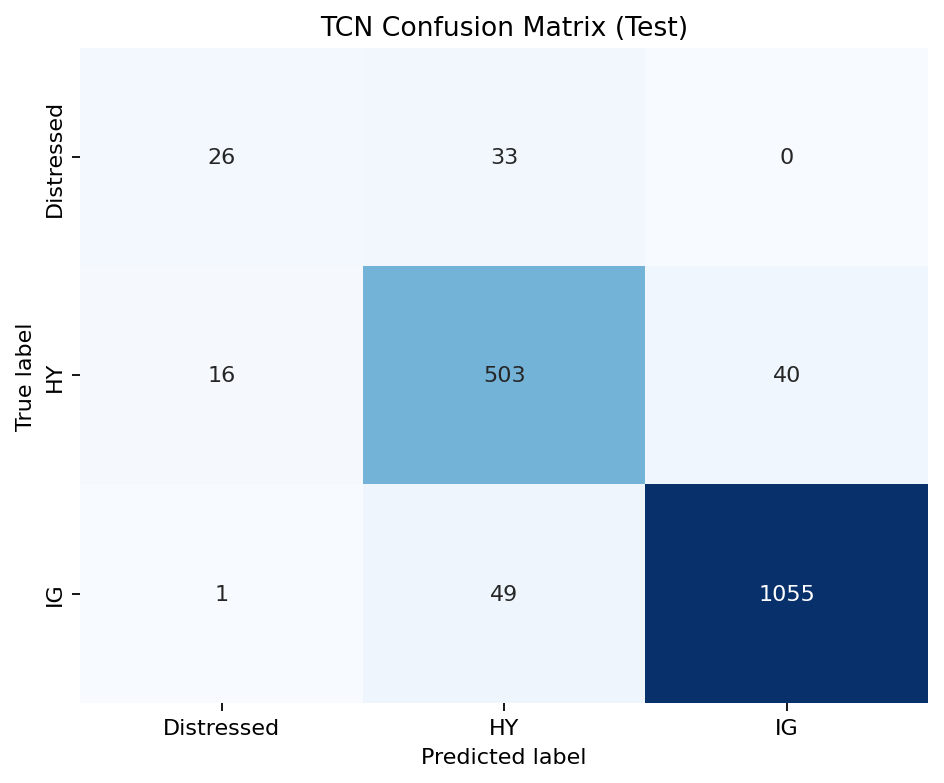

,Distressed,HY,IG
Distressed,26,33,0
HY,16,503,40
IG,1,49,1055


Classification report (test set):
              precision    recall  f1-score   support

  Distressed     0.6047    0.4407    0.5098        59
          HY     0.8598    0.8998    0.8794       559
          IG     0.9635    0.9548    0.9591      1105

    accuracy                         0.9193      1723
   macro avg     0.8093    0.7651    0.7828      1723
weighted avg     0.9176    0.9193    0.9178      1723

--- TEST SET EVALUATION ---
Accuracy: 0.9193
Precision (Weighted): 0.9176
Recall (Weighted):    0.9193
F1-macro:            0.7828
F1-weighted:         0.9178
QWK (Quadratic Weighted Kappa): 0.8614
AUC: 0.9534
---------------------------
Saved: /kaggle/working/credit_rating_artifacts/tcn_test_confusion_matrix.png
Saved: /kaggle/working/credit_rating_artifacts/tcn_test_confusion_matrix.csv
Saved: /kaggle/working/credit_rating_artifacts/tcn_test_classification_report.csv
Saved: /kaggle/working/credit_rating_artifacts/tcn_test_classification_report.csv


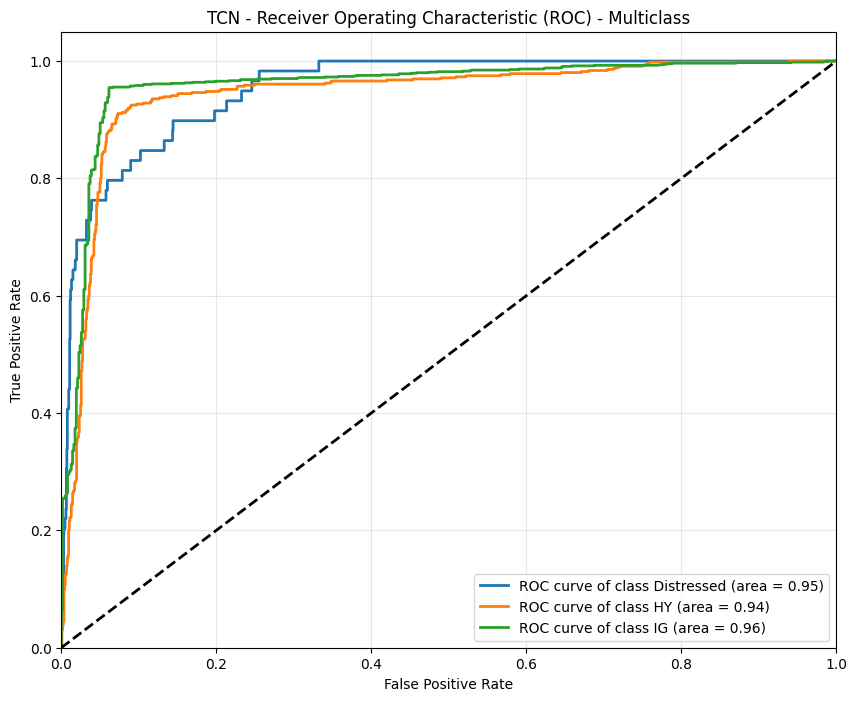

Saved: /kaggle/working/credit_rating_artifacts/tcn_test_roc_curves.png


In [7]:
if 'model' not in globals() or 'test_loader' not in globals():
    raise RuntimeError('Khong tim thay model/test_loader. Hay chay cell huan luyen truoc.')

from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_y_true, all_y_pred, all_logits = [], [], []

with torch.no_grad():
    for xb, lyb, sb, yb in test_loader:
        xb, lyb, sb = xb.to(device), lyb.to(device), sb.to(device)
        logits = model(xb, lyb, sb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_logits.append(logits.cpu())
        all_y_pred.append(preds)
        all_y_true.append(yb.numpy())

y_true = np.concatenate(all_y_true)
y_pred = np.concatenate(all_y_pred)
test_logits_all = torch.cat(all_logits)
test_proba = torch.softmax(test_logits_all, dim=1).numpy()

id_to_raw_local = {v: k for k, v in raw_to_id.items()} if 'raw_to_id' in globals() else {i: i for i in range(n_classes)}
class_labels = [str(id_to_raw_local.get(i, i)) for i in range(n_classes)]
label_ids = list(range(n_classes))

cm = confusion_matrix(y_true, y_pred, labels=label_ids)
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)

plt.figure(figsize=(6, 5), dpi=160)
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('TCN Confusion Matrix (Test)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
cm_plot_path = ARTIFACT_DIR / 'tcn_test_confusion_matrix.png'
plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
plt.show()

display(cm_df)
print('Classification report (test set):')
print(classification_report(
    y_true,
    y_pred,
    labels=label_ids,
    target_names=class_labels,
    digits=4,
    zero_division=0,
))

cls_report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        labels=label_ids,
        target_names=class_labels,
        output_dict=True,
        zero_division=0,
    )
).transpose()

cm_csv_path = ARTIFACT_DIR / 'tcn_test_confusion_matrix.csv'
cls_csv_path = ARTIFACT_DIR / 'tcn_test_classification_report.csv'
cm_df.to_csv(cm_csv_path, encoding='utf-8-sig')
cls_report_df.to_csv(cls_csv_path, encoding='utf-8-sig')

from sklearn.metrics import precision_score, recall_score

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)

try:
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
    auc_score = roc_auc_score(y_true_bin, test_proba, average='weighted', multi_class='ovr')
except:
    auc_score = float('nan')

qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')

print('--- TEST SET EVALUATION ---')
print(f'Accuracy: {acc:.4f}')
print(f'Precision (Weighted): {precision_weighted:.4f}')
print(f'Recall (Weighted):    {recall_weighted:.4f}')
print(f'F1-macro:            {f1_macro:.4f}')
print(f'F1-weighted:         {f1_weighted:.4f}')
print(f'QWK (Quadratic Weighted Kappa): {qwk:.4f}')
print(f'AUC: {auc_score:.4f}')
print('---------------------------')

metrics_summary = {
    'accuracy': acc,
    'precision_weighted': precision_weighted,
    'recall_weighted': recall_weighted,
    'f1_macro': f1_macro,
    'f1_weighted': f1_weighted,
    'qwk': qwk,
    'auc': auc_score,
}

test_metrics_df = pd.DataFrame([metrics_summary])
test_metrics_path = ARTIFACT_DIR / 'tcn_test_classification_report.csv'
test_metrics_df.to_csv(test_metrics_path, index=False)

print('Saved:', cm_plot_path)
print('Saved:', cm_csv_path)
print('Saved:', cls_csv_path)
print(f'Saved: {test_metrics_path}')

plt.figure(figsize=(10, 8))
y_test_bin = label_binarize(y_true, classes=list(range(n_classes)))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc_val:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('TCN - Receiver Operating Characteristic (ROC) - Multiclass')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
roc_plot_path = ARTIFACT_DIR / 'tcn_test_roc_curves.png'
plt.savefig(roc_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', roc_plot_path)

## xAI Captum GradientSHAP + LIME Interpretation

Phan xAI duoc trinh bay theo huong paper-ready cho bai toan xep hang tin dung doanh nghiep:

1. **Global Captum GradientSHAP drivers**: cac feature tai chinh/delta nao anh huong lon nhat tren tap test.
2. **Local "Why this class?"**: voi tung doanh nghiep mau, tach feature dang ung ho va chong lai lop duoc giai thich.
3. **Per-class explanation**: giai thich tung lop rating, khong chi lop argmax, de so sanh cac lop gan nhau theo ordinal risk.
4. **LIME local consistency**: LIME dung cung view feature tai chinh voi SHAP, nhung probability mac dinh lay truc tiep tu model/fusion output cua notebook.
5. **Temporal/fusion context**: baseline neural uu tien financial sequence view; ensemble/DMF giai thich tren probability inputs vi day la input that cua tang ket hop.

Luu y: GradientSHAP/LIME giai thich hanh vi cua model, khong duoc dien giai nhu quan he nhan qua tai chinh.


[INFO] xAI for TCN: rows=1723, feature_source=original_financial_sequence_mean, probability_source=test_proba
[INFO] GradientSHAP and LIME use the same xAI probability function for local consistency.
[INFO] Direct model probabilities are used when the notebook exposes them; otherwise a compact differentiable probability head is fitted to the notebook outputs.
[INFO] Explained classes: ['Distressed', 'HY', 'IG']
[INFO] xAI probability-head fidelity: {'proxy_mse': 0.06147378357493075, 'proxy_argmax_agreement': 0.8473592571096924}


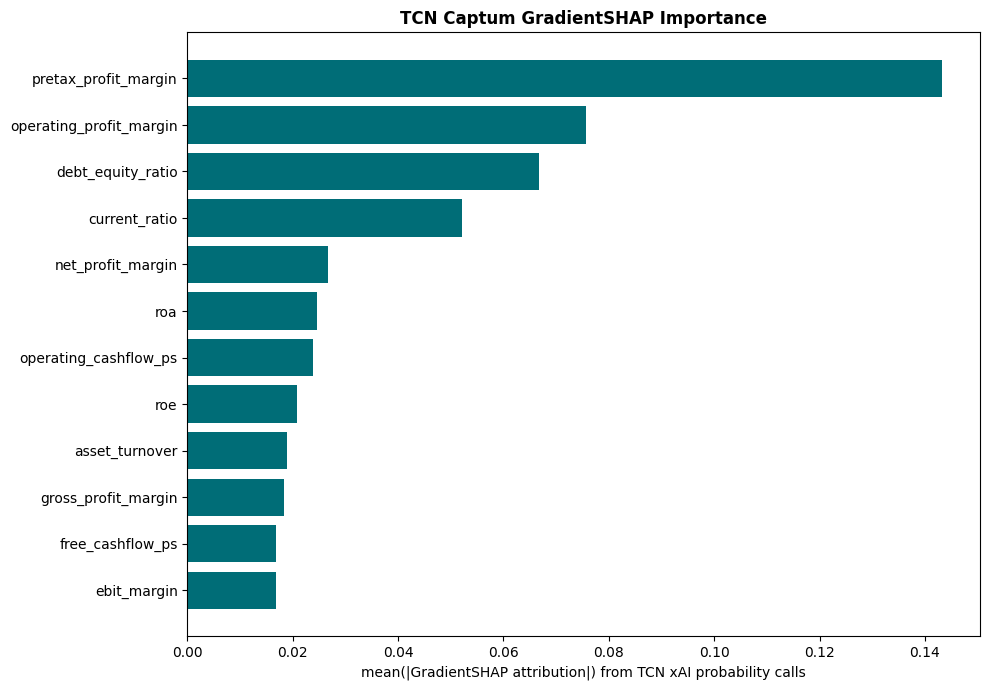

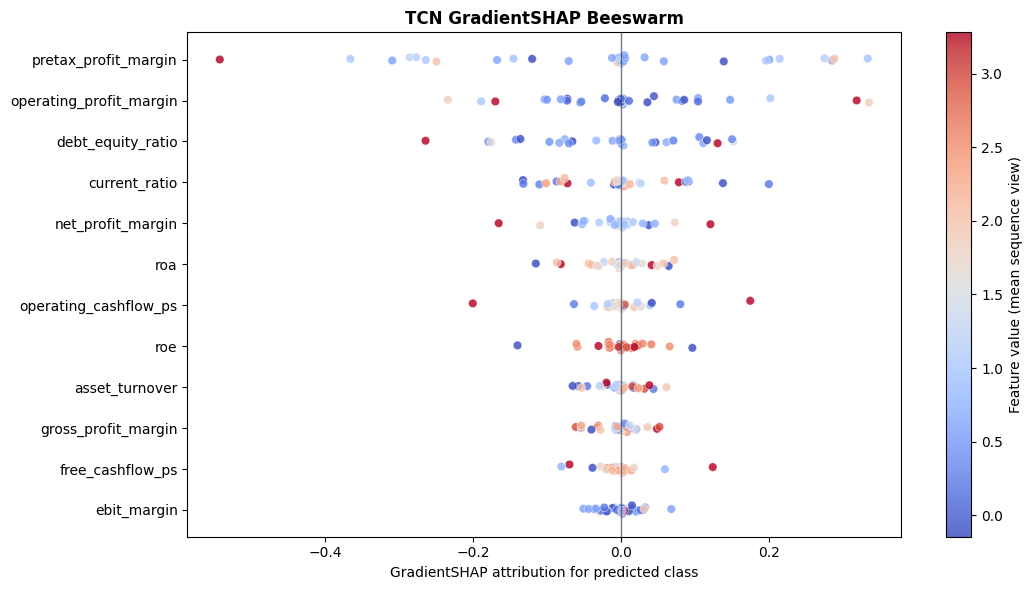


=== Captum GradientSHAP: Why this class? ===

--- Test index 210 | TCN predicted class=Distressed | predicted_proba=0.9408 ---
Why this class? class=Distressed | model_proba=0.9408
  opposes_explained_class    | free_cashflow_ps                              | attribution=-0.01206
  opposes_explained_class    | operating_cashflow_ps                         | attribution=-0.00368
  supports_explained_class   | asset_turnover                                | attribution=+0.00242
  opposes_explained_class    | current_ratio                                 | attribution=-0.00211
  supports_explained_class   | debt_equity_ratio                             | attribution=+0.00175
Why this class? class=HY | model_proba=0.0579
  supports_explained_class   | pretax_profit_margin                          | attribution=+1.30311
  opposes_explained_class    | operating_profit_margin                       | attribution=-0.84654
  supports_explained_class   | free_cashflow_ps                         

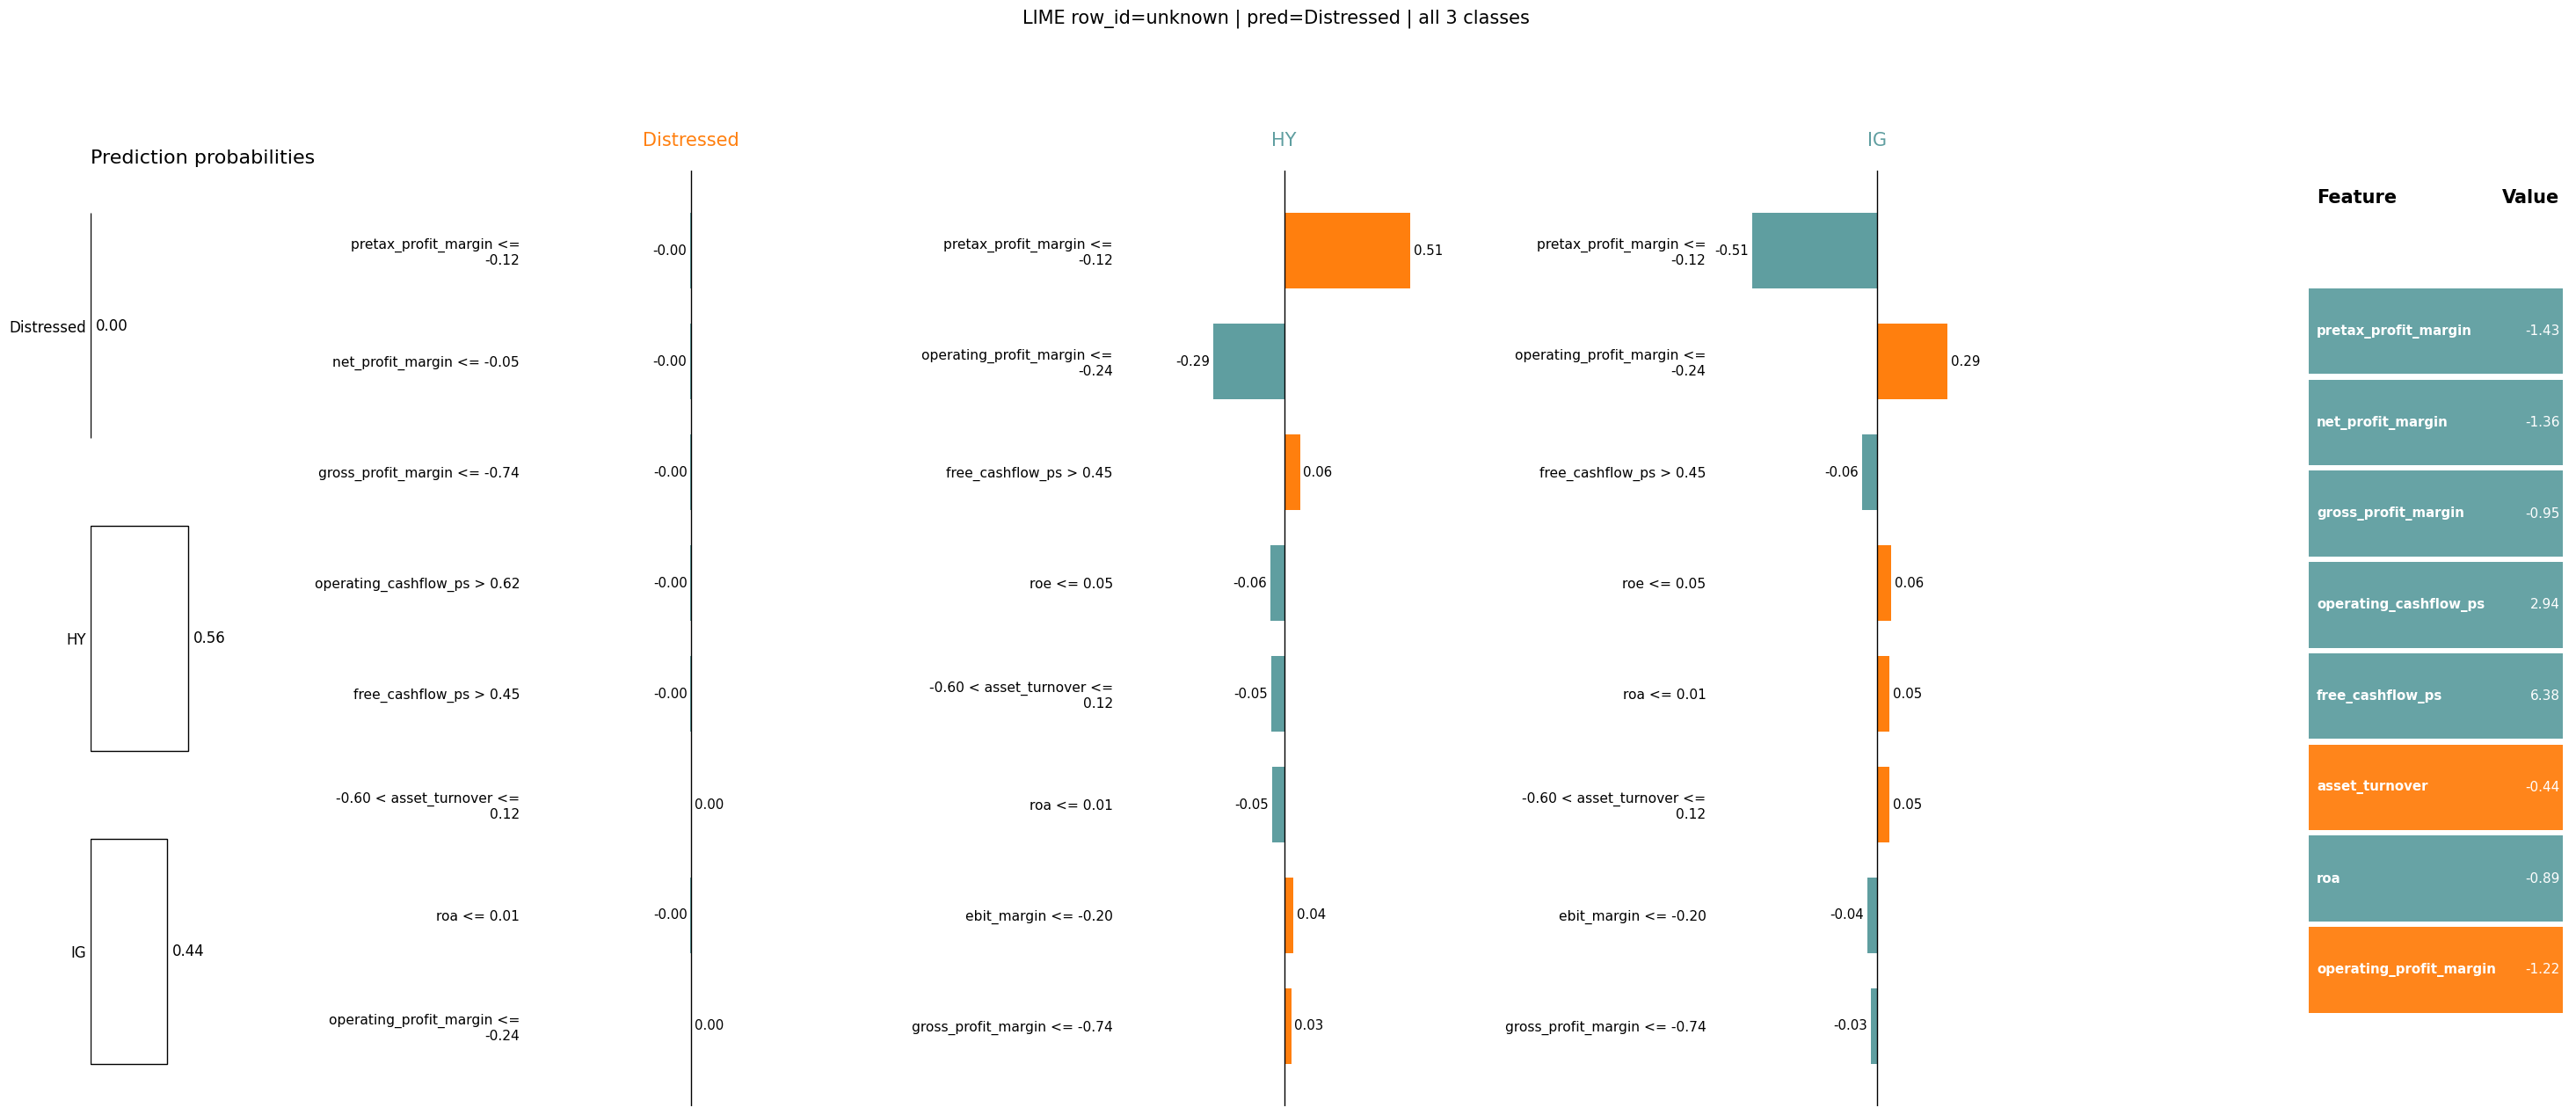

Why this class? class=Distressed | model_proba=0.9408 | lime_proba=0.0001
  opposes_explained_class    | pretax_profit_margin <= -0.12                 | weight=-0.00456
  opposes_explained_class    | net_profit_margin <= -0.05                    | weight=-0.00282
  opposes_explained_class    | gross_profit_margin <= -0.74                  | weight=-0.00225
  opposes_explained_class    | operating_cashflow_ps > 0.62                  | weight=-0.00219
  opposes_explained_class    | free_cashflow_ps > 0.45                       | weight=-0.00217
Why this class? class=HY | model_proba=0.0579 | lime_proba=0.5605
  supports_explained_class   | pretax_profit_margin <= -0.12                 | weight=+0.51405
  opposes_explained_class    | operating_profit_margin <= -0.24              | weight=-0.28704
  supports_explained_class   | free_cashflow_ps > 0.45                       | weight=+0.06422
  opposes_explained_class    | roe <= 0.05                                   | weight=-0.05728
  opp

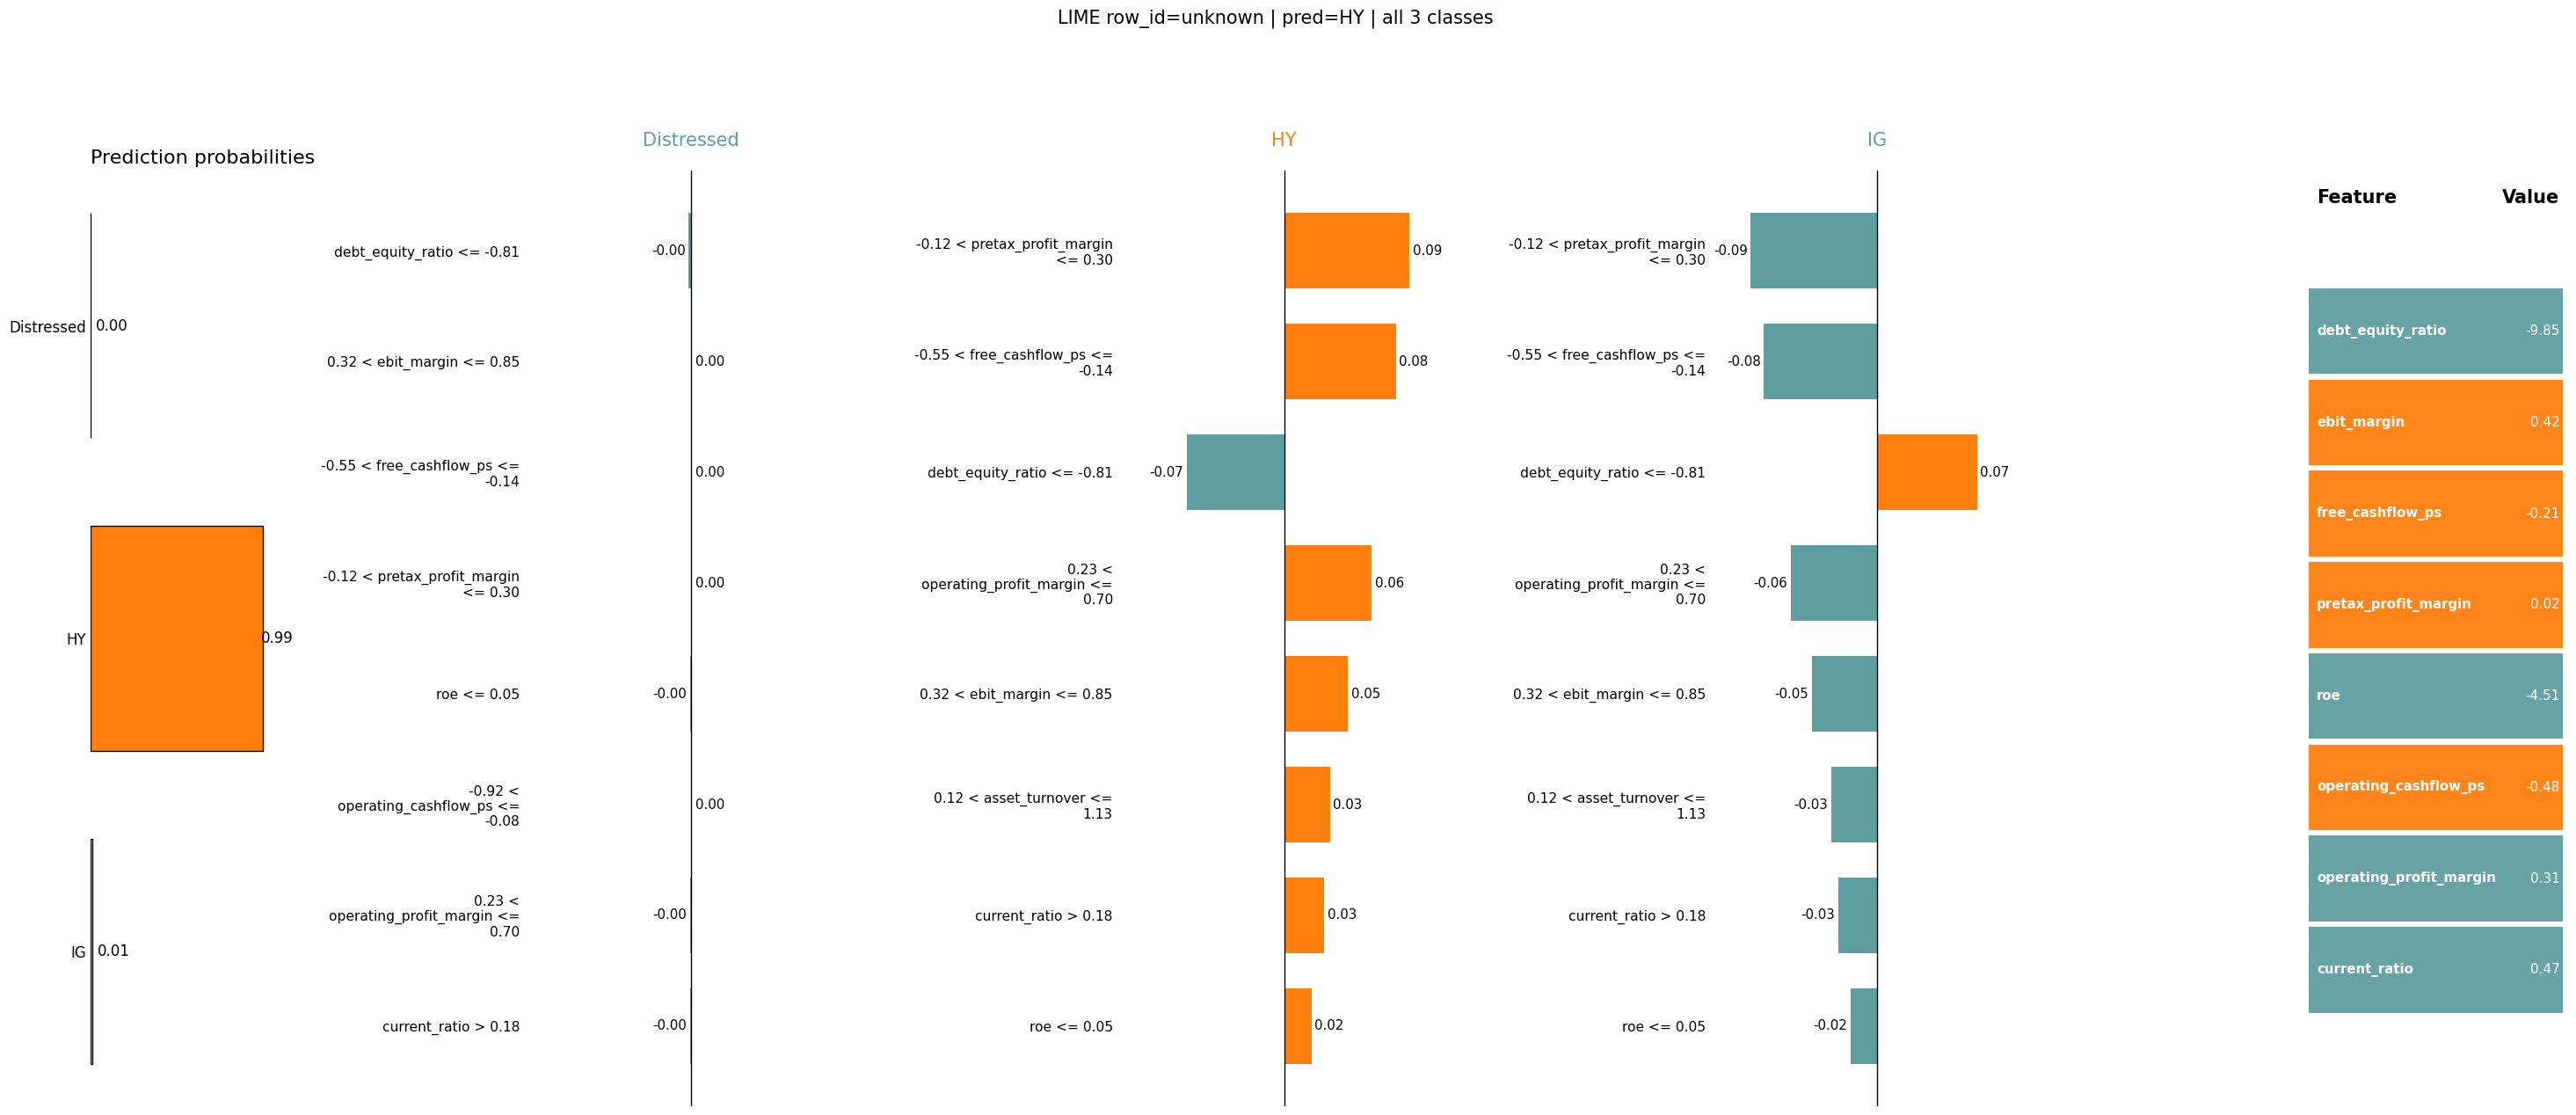

Why this class? class=Distressed | model_proba=0.0004 | lime_proba=0.0000
  opposes_explained_class    | debt_equity_ratio <= -0.81                    | weight=-0.00150
  supports_explained_class   | 0.32 < ebit_margin <= 0.85                    | weight=+0.00095
  supports_explained_class   | -0.55 < free_cashflow_ps <= -0.14             | weight=+0.00091
  supports_explained_class   | -0.12 < pretax_profit_margin <= 0.30          | weight=+0.00081
  opposes_explained_class    | roe <= 0.05                                   | weight=-0.00081
Why this class? class=HY | model_proba=0.9987 | lime_proba=0.9889
  supports_explained_class   | -0.12 < pretax_profit_margin <= 0.30          | weight=+0.08837
  supports_explained_class   | -0.55 < free_cashflow_ps <= -0.14             | weight=+0.07889
  opposes_explained_class    | debt_equity_ratio <= -0.81                    | weight=-0.06871
  supports_explained_class   | 0.23 < operating_profit_margin <= 0.70        | weight=+0.06182
  sup

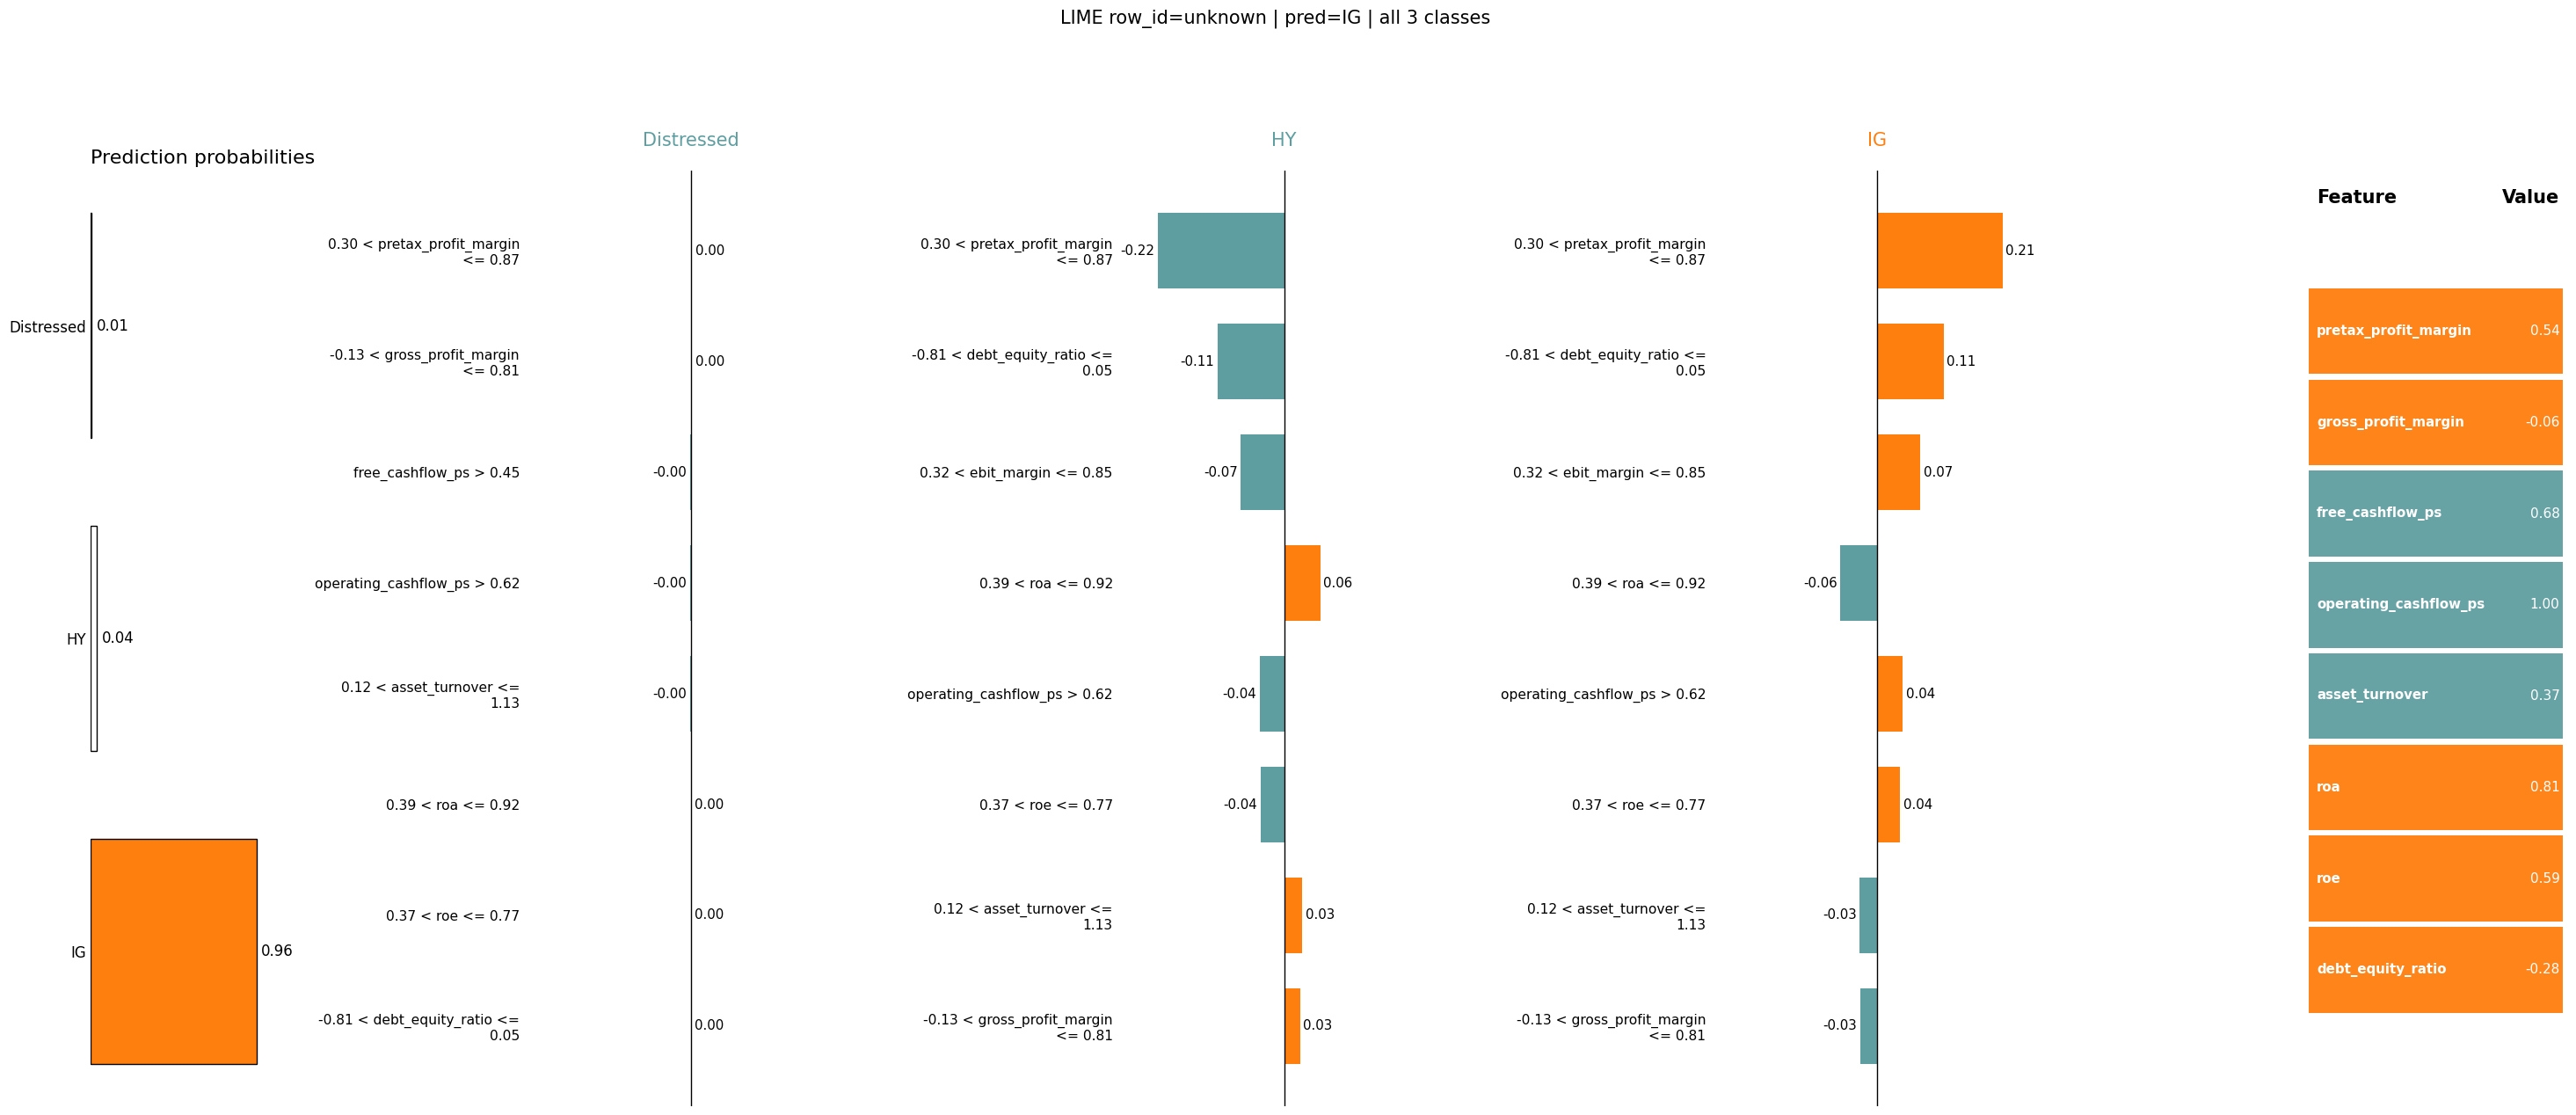

Why this class? class=Distressed | model_proba=0.0000 | lime_proba=0.0085
  supports_explained_class   | 0.30 < pretax_profit_margin <= 0.87           | weight=+0.00194
  supports_explained_class   | -0.13 < gross_profit_margin <= 0.81           | weight=+0.00179
  opposes_explained_class    | free_cashflow_ps > 0.45                       | weight=-0.00177
  opposes_explained_class    | operating_cashflow_ps > 0.62                  | weight=-0.00168
  opposes_explained_class    | 0.12 < asset_turnover <= 1.13                 | weight=-0.00152
Why this class? class=HY | model_proba=0.0051 | lime_proba=0.0350
  opposes_explained_class    | 0.30 < pretax_profit_margin <= 0.87           | weight=-0.21636
  opposes_explained_class    | -0.81 < debt_equity_ratio <= 0.05             | weight=-0.11376
  opposes_explained_class    | 0.32 < ebit_margin <= 0.85                    | weight=-0.07429
  supports_explained_class   | 0.39 < roa <= 0.92                            | weight=+0.06201
  opp

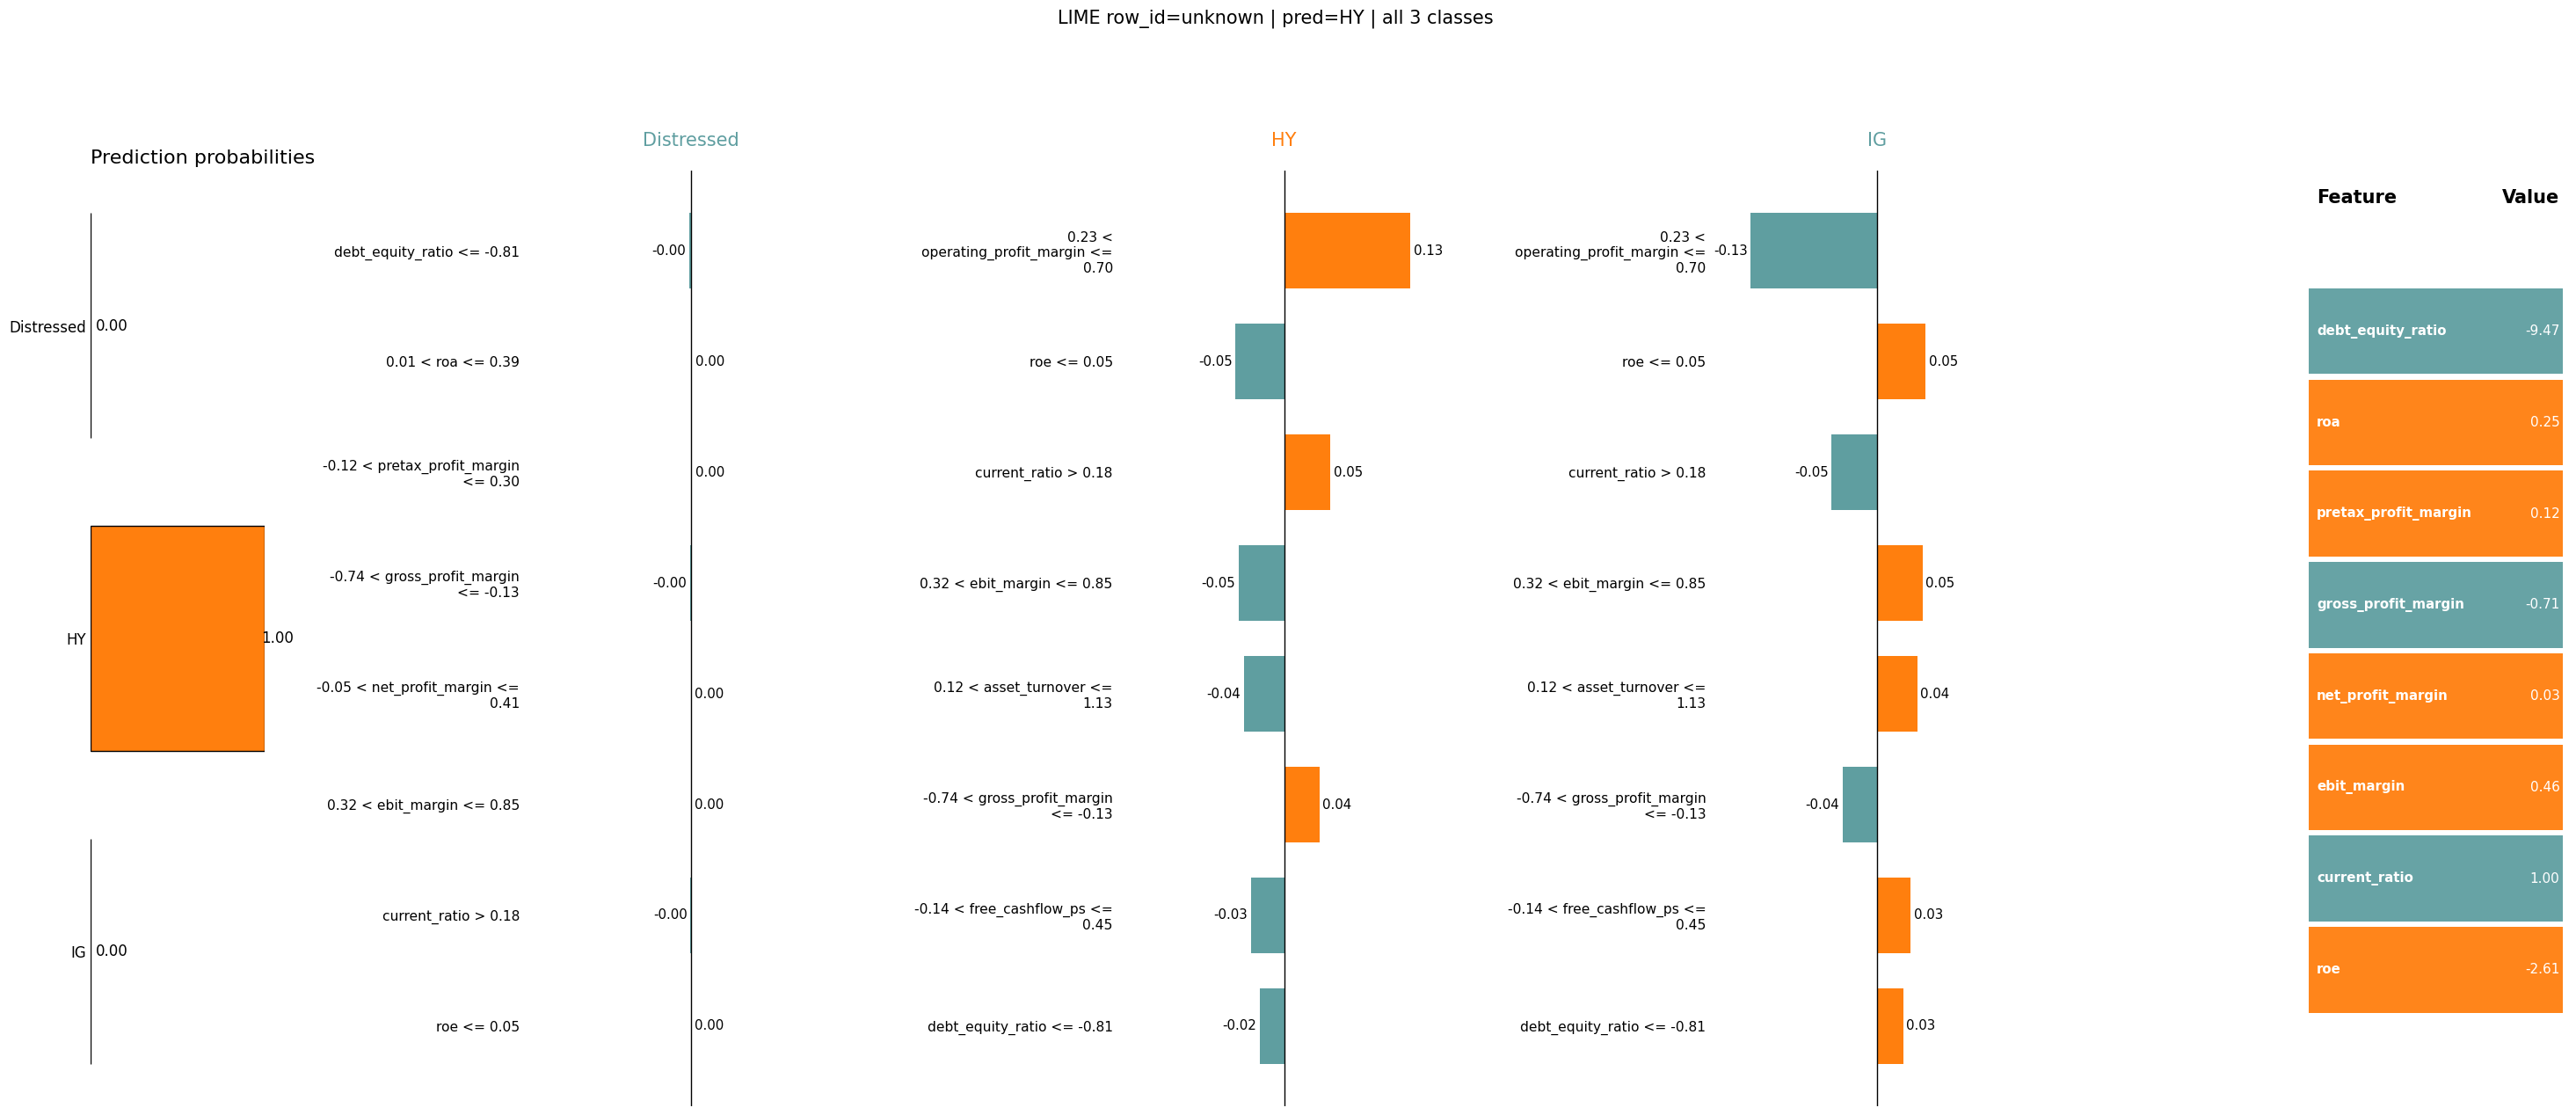

Why this class? class=Distressed | model_proba=0.0007 | lime_proba=0.0000
  opposes_explained_class    | debt_equity_ratio <= -0.81                    | weight=-0.00180
  supports_explained_class   | 0.01 < roa <= 0.39                            | weight=+0.00131
  supports_explained_class   | -0.12 < pretax_profit_margin <= 0.30          | weight=+0.00112
  opposes_explained_class    | -0.74 < gross_profit_margin <= -0.13          | weight=-0.00085
  supports_explained_class   | -0.05 < net_profit_margin <= 0.41             | weight=+0.00064
Why this class? class=HY | model_proba=0.9980 | lime_proba=0.9988
  supports_explained_class   | 0.23 < operating_profit_margin <= 0.70        | weight=+0.12972
  opposes_explained_class    | roe <= 0.05                                   | weight=-0.04974
  supports_explained_class   | current_ratio > 0.18                          | weight=+0.04743
  opposes_explained_class    | 0.32 < ebit_margin <= 0.85                    | weight=-0.04695
  opp

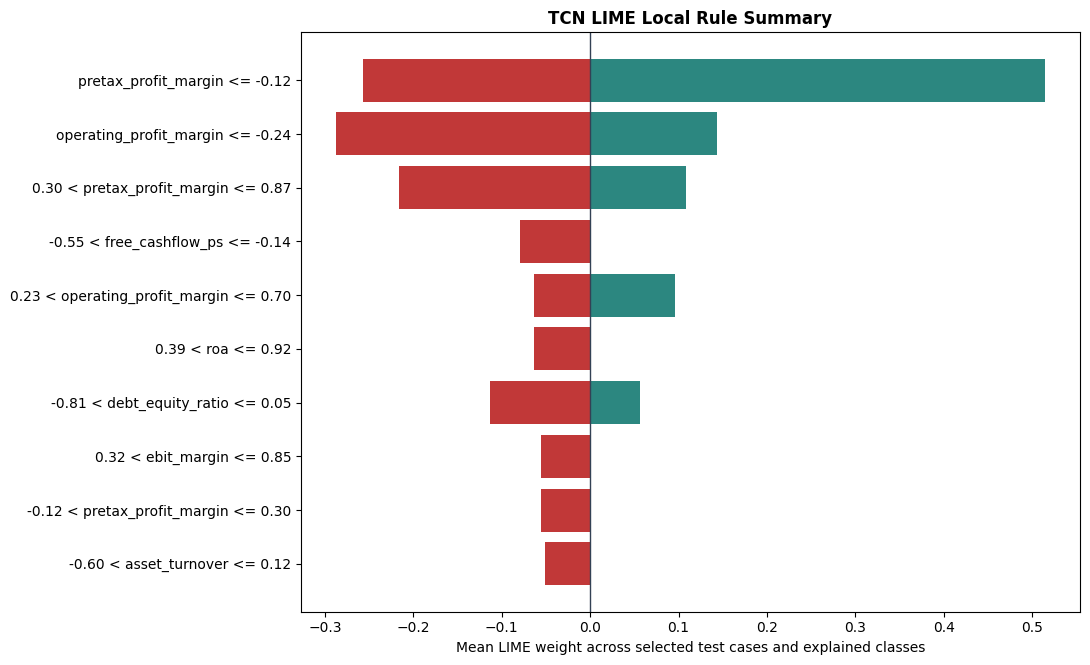

Saved: /kaggle/working/credit_rating_artifacts/tcn_financial_lime_rule_summary.png
Saved per-class local LIME decision explanations to: /kaggle/working/credit_rating_artifacts/tcn_financial_lime_local_decisions.csv


In [8]:
# ============================================================
# xAI Captum GradientSHAP + LIME aligned with Transformer-LSTM presentation
# Main artifacts:
#   {model_key}_financial_shap_importance_by_class.csv
#   {model_key}_financial_shap_global_importance.csv
#   {model_key}_financial_shap_local_decisions.csv
#   {model_key}_financial_lime_local_decisions.csv
# ============================================================
SHAP_FINANCIAL_ENABLED = True
LIME_FINANCIAL_ENABLED = True
XAI_MODEL_KEY = "tcn"
XAI_MODEL_LABEL = "TCN"
XAI_RANDOM_STATE = SEED if "SEED" in globals() else 42
XAI_LOCAL_SAMPLE_COUNT = 4
XAI_LOCAL_TOP_FEATURES = 10
XAI_FINANCIAL_REDUCER = "mean"  # {"mean", "last"}; used when reducing sequence windows.
XAI_EXPLAIN_CLASS_IDS = None  # None = explain all classes; set e.g. [0, 2] to focus.
XAI_ROW_IDS = None  # Optional explicit row_id list for local case studies.
XAI_BACKGROUND_SIZE = 80
SHAP_MAX_SAMPLES = 12
GRADIENT_SHAP_N_SAMPLES = 64
GRADIENT_SHAP_STDEV = 0.05
XAI_PROXY_MAX_ROWS = 2500
XAI_PROXY_EPOCHS = 220
LIME_NUM_SAMPLES = 600
LIME_USE_DIRECT_MODEL_PROBA = True
XAI_BEESWARM_TOP_FEATURES = 15
XAI_LIME_PLOT_TOP_RULES = 15
XAI_LIME_INSTANCE_TOP_RULES = 8

import math
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
except Exception as exc:
    raise RuntimeError("xAI GradientSHAP requires PyTorch for the differentiable attribution head.") from exc


def _xai_artifact_dir():
    path = globals().get("ARTIFACT_DIR", globals().get("DMF_ARTIFACT_DIR", None))
    if path is None:
        path = Path("/kaggle/working/credit_rating_artifacts") if globals().get("IN_KAGGLE", False) else Path("credit_rating_artifacts")
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def _xai_normalize_proba(pred):
    pred = np.asarray(pred, dtype=np.float64)
    if pred.ndim == 1:
        pred = pred.reshape(1, -1)
    pred = np.clip(pred, 1e-9, 1.0)
    return pred / pred.sum(axis=1, keepdims=True)


def _xai_class_names(n_cls):
    if "class_names" in globals() and len(class_names) > 0:
        names = [str(x) for x in class_names]
        return names[:n_cls] if len(names) >= n_cls else names + [str(i) for i in range(len(names), n_cls)]
    if "id_to_name" in globals():
        return [str(id_to_name.get(i, i)) for i in range(n_cls)]
    if "id_to_raw" in globals():
        return [str(id_to_raw.get(i, i)) for i in range(n_cls)]
    if "raw_to_id" in globals():
        inv = {int(v): k for k, v in raw_to_id.items()}
        return [str(inv.get(i, i)) for i in range(n_cls)]
    if "le" in globals() and hasattr(le, "classes_"):
        names = [str(x) for x in le.classes_]
        return names[:n_cls] if len(names) >= n_cls else names + [str(i) for i in range(len(names), n_cls)]
    return [str(i) for i in range(n_cls)]


def _xai_resolve_class_ids(class_ids, n_cls):
    if class_ids is None:
        return list(range(n_cls))
    out = []
    for class_id in class_ids:
        class_id = int(class_id)
        if class_id < 0 or class_id >= n_cls:
            raise ValueError(f"Invalid xAI class id {class_id}; expected 0..{n_cls - 1}.")
        if class_id not in out:
            out.append(class_id)
    if not out:
        raise ValueError("XAI_EXPLAIN_CLASS_IDS resolved to an empty class list.")
    return out


def _xai_prob_columns(frame, prefix=None):
    if prefix is None:
        cols = [c for c in frame.columns if str(c).startswith("prob_")]
    else:
        cols = [c for c in frame.columns if str(c).startswith(f"{prefix}_prob_")]

    def suffix_num(name):
        try:
            return int(str(name).split("_")[-1])
        except Exception:
            return 10**9
    return sorted(cols, key=suffix_num)


def _xai_get_proba():
    for name in ["dmf_probs", "fp", "test_proba", "test_probs", "weighted_probs", "soft_probs", "y_test_proba"]:
        if name in globals():
            arr = np.asarray(globals()[name])
            if arr.ndim == 2 and arr.shape[0] > 0:
                return _xai_normalize_proba(arr), name
    if "model" in globals() and "X_test" in globals() and hasattr(model, "predict_proba"):
        X_arr = X_test.values if isinstance(X_test, pd.DataFrame) else np.asarray(X_test)
        return _xai_normalize_proba(model.predict_proba(X_arr)), "model.predict_proba(X_test)"
    for frame_name in ["test_predictions", "test_results", "test_result_df", "test_results_df", "out"]:
        if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame):
            frame = globals()[frame_name]
            cols = _xai_prob_columns(frame)
            if cols:
                return _xai_normalize_proba(frame[cols].to_numpy(dtype=float)), frame_name
    raise RuntimeError("Kh?ng t?m th?y probability matrix cho xAI. H?y ch?y cell inference/evaluation tr??c.")


_XAI_CANONICAL_FINANCIAL_FEATURES = [
    "current_ratio",
    "debt_equity_ratio",
    "gross_profit_margin",
    "operating_profit_margin",
    "ebit_margin",
    "pretax_profit_margin",
    "net_profit_margin",
    "asset_turnover",
    "roe",
    "roa",
    "operating_cashflow_ps",
    "free_cashflow_ps",
]


def _xai_original_financial_feature_names():
    out = []
    for source_name in ["FINANCIAL_FEATURES", "MODEL_FEATURES", "feature_cols", "financial_cols"]:
        values = globals().get(source_name, [])
        if values is None:
            continue
        try:
            names = [str(v) for v in values]
        except TypeError:
            continue
        for col in _XAI_CANONICAL_FINANCIAL_FEATURES:
            if col in names and col not in out:
                out.append(col)
    return out if out else list(_XAI_CANONICAL_FINANCIAL_FEATURES)


def _xai_financial_indices_from_names(names):
    names = [str(c) for c in names]
    wanted = _xai_original_financial_feature_names()
    cols = [c for c in wanted if c in names]
    idx = [names.index(c) for c in cols]
    return idx, cols


def _xai_frame_financial_values(frame):
    cols = [c for c in _xai_original_financial_feature_names() if c in frame.columns]
    if cols:
        return frame[cols].to_numpy(dtype=np.float64), [str(c) for c in cols]
    return None, []


def _xai_reduce_sequence_to_original_financial(seq, candidate_names):
    seq = np.asarray(seq, dtype=np.float64)
    idx, cols = _xai_financial_indices_from_names(candidate_names)
    if idx:
        return seq[:, :, idx].mean(axis=1), cols
    return seq.mean(axis=1), [str(c) for c in candidate_names]


def _xai_get_feature_view(proba):
    if "test_ds" in globals() and hasattr(test_ds, "samples") and len(test_ds.samples) > 0:
        seq = np.stack([s[0] for s in test_ds.samples], axis=0).astype(np.float64)
        candidate_names = globals().get("MODEL_FEATURES", globals().get("FINANCIAL_FEATURES", [f"feature_{i}" for i in range(seq.shape[-1])]))
        X_fin, financial_cols = _xai_reduce_sequence_to_original_financial(seq, candidate_names)
        return X_fin, financial_cols, "original_financial_sequence_mean"
    if "test_X_all" in globals():
        arr = np.asarray(test_X_all, dtype=np.float64)
        if arr.ndim == 3:
            candidate_names = globals().get("MODEL_FEATURES", globals().get("FINANCIAL_FEATURES", [f"feature_{i}" for i in range(arr.shape[-1])]))
            X_fin, financial_cols = _xai_reduce_sequence_to_original_financial(arr, candidate_names)
            return X_fin, financial_cols, "original_financial_sequence_mean"
        if arr.ndim == 2:
            candidate_names = globals().get("flat_feature_names", [f"feature_{i}" for i in range(arr.shape[1])])
            idx, financial_cols = _xai_financial_indices_from_names(candidate_names)
            if idx:
                return arr[:, idx], financial_cols, "original_financial_flat_features"
            if "MODEL_FEATURES" in globals() and arr.shape[1] == len(MODEL_FEATURES):
                idx, financial_cols = _xai_financial_indices_from_names(MODEL_FEATURES)
                if idx:
                    return arr[:, idx], financial_cols, "original_financial_tabular_features"
            return arr, [str(c) for c in candidate_names], "flattened_sequence"
    if "X_test" in globals():
        if isinstance(X_test, pd.DataFrame):
            X_fin, financial_cols = _xai_frame_financial_values(X_test)
            if financial_cols:
                return X_fin, financial_cols, "original_financial_tabular_features"
            arr = X_test.values
        else:
            arr = np.asarray(X_test)
        arr = np.asarray(arr, dtype=np.float64)
        if "MODEL_FEATURES" in globals() and arr.ndim == 2 and arr.shape[1] == len(MODEL_FEATURES):
            idx, financial_cols = _xai_financial_indices_from_names(MODEL_FEATURES)
            if idx:
                return arr[:, idx], financial_cols, "original_financial_tabular_features"
        if "MODEL_FEATURES" in globals() and "INPUT_SIZE" in globals() and arr.ndim == 2 and arr.shape[1] >= int(INPUT_SIZE) * len(MODEL_FEATURES):
            n_base = len(MODEL_FEATURES)
            window = arr[:, :int(INPUT_SIZE) * n_base].reshape(arr.shape[0], int(INPUT_SIZE), n_base)
            idx, financial_cols = _xai_financial_indices_from_names(MODEL_FEATURES)
            if idx:
                return window[:, :, idx].mean(axis=1), financial_cols, "original_financial_tabular_window_mean"
        cols = list(X_test.columns) if isinstance(X_test, pd.DataFrame) else [f"feature_{i}" for i in range(arr.shape[1])]
        idx, financial_cols = _xai_financial_indices_from_names(cols)
        if idx:
            return arr[:, idx], financial_cols, "original_financial_tabular_features"
        return arr, [str(c) for c in cols], "tabular_features"
    if "df" in globals() and "test_mask" in globals():
        mask = test_mask.detach().cpu().numpy() if hasattr(test_mask, "detach") else np.asarray(test_mask)
        frame = df.loc[mask].reset_index(drop=True)
        X_fin, financial_cols = _xai_frame_financial_values(frame)
        if financial_cols:
            return X_fin, financial_cols, "df_test_mask_original_financial_features"
    for frame_name in ["test_df", "df_test", "test_rows", "out"]:
        if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame):
            frame = globals()[frame_name]
            X_fin, financial_cols = _xai_frame_financial_values(frame)
            if financial_cols:
                return X_fin, financial_cols, f"{frame_name}_original_financial_features"
            prob_cols = []
            for prefix in ["tlstm", "gat", "lstm", "tcn", "patchtst", "xgboost", "lightgbm", "dmf"]:
                prob_cols.extend(_xai_prob_columns(frame, prefix=prefix))
            if prob_cols:
                return frame[prob_cols].to_numpy(dtype=np.float64), [str(c) for c in prob_cols], f"{frame_name}_probability_inputs"
    if "test_probas" in globals() and isinstance(test_probas, list) and len(test_probas) > 0:
        mats = [np.asarray(p, dtype=np.float64) for p in test_probas]
        if all(m.ndim == 2 for m in mats):
            names = globals().get("MODEL_NAMES", [f"model_{i}" for i in range(len(mats))])
            feature_cols = []
            for model_name, mat in zip(names, mats):
                for class_idx in range(mat.shape[1]):
                    feature_cols.append(f"{model_name}_prob_{class_idx}")
            return np.concatenate(mats, axis=1), feature_cols, "ensemble_probability_inputs"
    return np.asarray(proba, dtype=np.float64), [f"predicted_prob_{i}" for i in range(proba.shape[1])], "model_probability_vector"


def _xai_metadata(n_rows):
    meta_cols = ["row_id", "ticker", "company_name", "rating_date", "sector", "true_label", "true_label_name"]
    for frame_name in ["test_df", "df_test", "test_rows", "out", "test_predictions", "test_results_df"]:
        if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame) and len(globals()[frame_name]) >= n_rows:
            frame = globals()[frame_name].reset_index(drop=True)
            cols = [c for c in meta_cols if c in frame.columns]
            if cols:
                return frame.loc[:n_rows - 1, cols].copy()
    if "df" in globals() and "test_mask" in globals():
        mask = test_mask.detach().cpu().numpy() if hasattr(test_mask, "detach") else np.asarray(test_mask)
        frame = df.loc[mask].reset_index(drop=True)
        cols = [c for c in meta_cols if c in frame.columns]
        if cols and len(frame) >= n_rows:
            return frame.loc[:n_rows - 1, cols].copy()
    meta = pd.DataFrame({"test_index": np.arange(n_rows, dtype=int)})
    if "y_test" in globals() and len(y_test) >= n_rows:
        meta["true_label"] = np.asarray(y_test[:n_rows], dtype=int)
    elif "y_true" in globals() and len(y_true) >= n_rows:
        meta["true_label"] = np.asarray(y_true[:n_rows], dtype=int)
    return meta


def _xai_select_indices(meta, proba):
    n_rows = len(meta)
    if XAI_ROW_IDS is not None and "row_id" in meta.columns:
        wanted = {str(x) for x in XAI_ROW_IDS}
        idx = [int(i) for i, row_id in enumerate(meta["row_id"].astype(str)) if row_id in wanted]
        if idx:
            return idx[:XAI_LOCAL_SAMPLE_COUNT]
    confidence = proba.max(axis=1)
    ranked = np.argsort(-confidence)
    selected = []
    preds = proba.argmax(axis=1)
    for class_id in np.unique(preds[ranked]):
        class_ranked = [int(i) for i in ranked if preds[i] == class_id]
        if class_ranked:
            selected.append(class_ranked[0])
        if len(selected) >= XAI_LOCAL_SAMPLE_COUNT:
            break
    for i in ranked:
        i = int(i)
        if i not in selected:
            selected.append(i)
        if len(selected) >= XAI_LOCAL_SAMPLE_COUNT:
            break
    return selected


class _XAIProbabilityHead(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        hidden = int(min(96, max(16, 2 * n_features)))
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return torch.softmax(self.net(x.float()), dim=1)


def _xai_train_probability_head(X_view, proba):
    rng = np.random.default_rng(XAI_RANDOM_STATE)
    X_view = np.asarray(X_view, dtype=np.float64)
    proba = _xai_normalize_proba(proba)
    center = np.nanmedian(X_view, axis=0)
    scale = np.nanstd(X_view, axis=0)
    scale = np.where(scale < 1e-8, 1.0, scale)
    X_std = np.nan_to_num((X_view - center) / scale, nan=0.0, posinf=0.0, neginf=0.0)
    n_rows = len(X_std)
    fit_idx = np.arange(n_rows)
    if n_rows > XAI_PROXY_MAX_ROWS:
        fit_idx = rng.choice(n_rows, size=XAI_PROXY_MAX_ROWS, replace=False)
    device_xai = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    head = _XAIProbabilityHead(X_std.shape[1], proba.shape[1]).to(device_xai)
    x_train = torch.tensor(X_std[fit_idx], dtype=torch.float32, device=device_xai)
    y_train = torch.tensor(proba[fit_idx], dtype=torch.float32, device=device_xai)
    opt = torch.optim.AdamW(head.parameters(), lr=0.01, weight_decay=1e-4)
    head.train()
    for _ in range(int(XAI_PROXY_EPOCHS)):
        opt.zero_grad(set_to_none=True)
        pred = head(x_train)
        loss = torch.mean((pred - y_train) ** 2)
        loss.backward()
        opt.step()
    head.eval()
    with torch.no_grad():
        pred_all = head(torch.tensor(X_std, dtype=torch.float32, device=device_xai)).detach().cpu().numpy()
    fidelity = {
        "proxy_mse": float(np.mean((pred_all - proba) ** 2)),
        "proxy_argmax_agreement": float(np.mean(pred_all.argmax(axis=1) == proba.argmax(axis=1))),
    }
    return head, X_std.astype(np.float32), center, scale, device_xai, fidelity


def _xai_predict_from_head(head, center, scale, device_xai, x_batch):
    x_batch = np.asarray(x_batch, dtype=np.float64)
    if x_batch.ndim == 1:
        x_batch = x_batch.reshape(1, -1)
    x_std = np.nan_to_num((x_batch - center) / scale, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    with torch.no_grad():
        pred = head(torch.tensor(x_std, dtype=torch.float32, device=device_xai)).detach().cpu().numpy()
    return _xai_normalize_proba(pred)


def _xai_gradientshap_attributions(head, X_std, sample_indices, background_indices, class_ids, device_xai):
    x_samples = torch.tensor(X_std[sample_indices], dtype=torch.float32, device=device_xai)
    baselines = torch.tensor(X_std[background_indices], dtype=torch.float32, device=device_xai)
    method = "captum_gradientshap_probability_head"
    attributions = {}
    try:
        from captum.attr import GradientShap
        gs = GradientShap(head)
        for class_id in class_ids:
            attr = gs.attribute(
                x_samples,
                baselines=baselines,
                target=int(class_id),
                n_samples=int(GRADIENT_SHAP_N_SAMPLES),
                stdevs=float(GRADIENT_SHAP_STDEV),
            )
            attributions[int(class_id)] = attr.detach().cpu().numpy()
    except Exception as exc:
        method = f"expected_gradients_fallback: {type(exc).__name__}"
        rng = np.random.default_rng(XAI_RANDOM_STATE)
        for class_id in class_ids:
            rows = []
            for x_np in X_std[sample_indices]:
                accum = []
                for _ in range(int(GRADIENT_SHAP_N_SAMPLES)):
                    b_np = X_std[int(rng.choice(background_indices))]
                    alpha = float(rng.uniform(0.0, 1.0))
                    noise = rng.normal(0.0, float(GRADIENT_SHAP_STDEV), size=x_np.shape).astype(np.float32)
                    interp_np = b_np + alpha * (x_np - b_np) + noise
                    interp = torch.tensor(interp_np.reshape(1, -1), dtype=torch.float32, device=device_xai, requires_grad=True)
                    score = head(interp)[:, int(class_id)].sum()
                    grad = torch.autograd.grad(score, interp)[0].detach().cpu().numpy()[0]
                    accum.append((x_np - b_np) * grad)
                rows.append(np.mean(accum, axis=0))
            attributions[int(class_id)] = np.asarray(rows, dtype=np.float32)
    return attributions, method


def _xai_lime_fallback(x_row, predict_fn, class_id, feature_names, num_features):
    rng = np.random.default_rng(XAI_RANDOM_STATE + int(class_id))
    x_row = np.asarray(x_row, dtype=np.float64)
    perturb = rng.normal(loc=x_row, scale=np.maximum(np.nanstd(x_row), 1e-3), size=(int(LIME_NUM_SAMPLES), len(x_row)))
    perturb[0] = x_row
    probs = _xai_normalize_proba(predict_fn(perturb))[:, int(class_id)]
    distances = np.linalg.norm(perturb - x_row.reshape(1, -1), axis=1)
    kernel_width = math.sqrt(len(x_row)) * 0.75
    weights = np.exp(-(distances ** 2) / max(kernel_width ** 2, 1e-9))
    X_aug = np.column_stack([np.ones(len(perturb)), perturb - x_row.reshape(1, -1)])
    W = np.sqrt(weights).reshape(-1, 1)
    coef = np.linalg.lstsq(X_aug * W, probs * W.ravel(), rcond=None)[0][1:]
    order = np.argsort(-np.abs(coef))[:num_features]
    return [(str(feature_names[j]), float(coef[j])) for j in order]



def _xai_short_text(text, max_len=34):
    text = str(text)
    return text if len(text) <= int(max_len) else text[: max(1, int(max_len) - 3)] + "..."


def _xai_wrap_text(text, width=28, max_lines=3):
    import textwrap

    lines = textwrap.wrap(str(text), width=int(width), break_long_words=False, replace_whitespace=False)
    if not lines:
        return ""
    if len(lines) > int(max_lines):
        lines = lines[: int(max_lines)]
        lines[-1] = _xai_short_text(lines[-1], max(4, int(width) - 1))
    return "\n".join(lines)


def _xai_lime_rule_feature(rule, feature_names):
    rule_text = str(rule)
    for feature in sorted([str(f) for f in feature_names], key=len, reverse=True):
        if feature in rule_text:
            return feature
    return rule_text

def _xai_save_lime_multiclass_instance_plot(row_meta, exp, model_proba, lime_proba, x_row, html_path, lime_available):
    from matplotlib.patches import Rectangle

    row_id = str(row_meta.get("row_id", row_meta.get("test_index", "unknown")))
    safe_row_id = "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in row_id)
    class_ids = list(explain_class_ids)
    if lime_available and exp is not None:
        class_items = {
            int(class_id): exp.as_list(label=int(class_id))[: min(int(XAI_LIME_INSTANCE_TOP_RULES), int(XAI_LOCAL_TOP_FEATURES))]
            for class_id in class_ids
        }
    else:
        class_items = {
            int(class_id): _xai_lime_fallback(x_row, _xai_probability_fn, int(class_id), feature_cols, min(int(XAI_LIME_INSTANCE_TOP_RULES), int(XAI_LOCAL_TOP_FEATURES)))
            for class_id in class_ids
        }
    if not any(class_items.values()):
        return None

    support_color = "#ff7f0e"
    oppose_color = "#5f9ea0"
    pred_class = int(np.argmax(model_proba))
    all_weights = [abs(float(weight)) for items in class_items.values() for _, weight in items]
    common_max_abs = max(max(all_weights, default=1e-3), 1e-3)

    max_items = max(len(items) for items in class_items.values())
    fig_height = max(9.6, 1.18 * max_items + 4.2)
    fig_width = max(24.0, 10.5 + 6.6 * len(class_ids))
    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=False)
    gs = fig.add_gridspec(1, 2 + len(class_ids), width_ratios=[1.75] + [3.35] * len(class_ids) + [2.65], wspace=0.90)

    ax_prob = fig.add_subplot(gs[0, 0])
    prob_y = np.arange(len(class_names_xai))
    prob_colors = [support_color if i == pred_class else "white" for i in range(len(class_names_xai))]
    ax_prob.barh(prob_y, lime_proba, color=prob_colors, edgecolor="black", height=0.72)
    ax_prob.set_yticks(prob_y)
    ax_prob.set_yticklabels([_xai_wrap_text(name, 16, 2) for name in class_names_xai], fontsize=12)
    ax_prob.set_xlim(0, 1.0)
    ax_prob.set_xticks([])
    ax_prob.set_title("Prediction probabilities", fontsize=16, loc="left")
    for y, value in zip(prob_y, lime_proba):
        ax_prob.text(min(float(value) + 0.03, 0.98), y, f"{float(value):.2f}", va="center", fontsize=12)
    for spine in ax_prob.spines.values():
        spine.set_visible(False)
    ax_prob.tick_params(axis="y", length=0)
    ax_prob.invert_yaxis()

    for panel_idx, class_id in enumerate(class_ids, start=1):
        items = class_items[int(class_id)]
        ax_rules = fig.add_subplot(gs[0, panel_idx])
        if not items:
            ax_rules.axis("off")
            continue
        rule_labels = [_xai_wrap_text(rule, 28, 4) for rule, _ in items]
        weights = np.array([float(weight) for _, weight in items], dtype=float)
        y_pos = np.arange(len(items))
        bar_colors = [support_color if weight >= 0 else oppose_color for weight in weights]
        ax_rules.barh(y_pos, weights, color=bar_colors, height=0.68)
        ax_rules.axvline(0, color="black", linewidth=1.0)
        ax_rules.set_yticks(y_pos)
        ax_rules.set_yticklabels(rule_labels, fontsize=11.2, linespacing=1.15)
        ax_rules.set_xlim(-common_max_abs * 1.32, common_max_abs * 1.32)
        ax_rules.set_xticks([])
        title_color = support_color if int(class_id) == pred_class else oppose_color
        ax_rules.set_title(_xai_wrap_text(class_names_xai[int(class_id)], 16, 2), fontsize=15, color=title_color, pad=20)
        for y, weight in zip(y_pos, weights):
            x_text = weight + (0.025 * common_max_abs if weight >= 0 else -0.025 * common_max_abs)
            ha = "left" if weight >= 0 else "right"
            ax_rules.text(x_text, y, f"{weight:.2f}", va="center", ha=ha, fontsize=10.8)
        for spine in ax_rules.spines.values():
            spine.set_visible(False)
        ax_rules.tick_params(axis="y", length=0)
        ax_rules.invert_yaxis()

    ax_table = fig.add_subplot(gs[0, -1])
    ax_table.axis("off")
    ax_table.text(0.05, 0.98, "Feature", fontsize=15, fontweight="bold", va="top")
    ax_table.text(0.97, 0.98, "Value", fontsize=15, fontweight="bold", ha="right", va="top")
    seen_features = []
    feature_rows = []
    for _, items in class_items.items():
        for rule, weight in items:
            feat = _xai_lime_rule_feature(rule, feature_cols)
            if feat in seen_features:
                continue
            seen_features.append(feat)
            feat_value = np.nan
            if feat in feature_cols:
                feat_value = float(x_row[feature_cols.index(feat)])
            feature_rows.append((feat, feat_value, float(weight)))
            if len(feature_rows) >= int(XAI_LIME_INSTANCE_TOP_RULES):
                break
        if len(feature_rows) >= int(XAI_LIME_INSTANCE_TOP_RULES):
            break
    row_height = 0.78 / max(len(feature_rows), 1)
    for offset, (feat, feat_value, weight) in enumerate(feature_rows):
        y0 = 0.88 - (offset + 1) * row_height
        color = support_color if weight >= 0 else oppose_color
        ax_table.add_patch(Rectangle((0.02, y0), 0.96, row_height * 0.94, transform=ax_table.transAxes, facecolor=color, edgecolor="none", alpha=0.95))
        value_text = "" if not np.isfinite(feat_value) else f"{feat_value:.2f}"
        ax_table.text(0.05, y0 + row_height * 0.47, _xai_wrap_text(feat, 15, 3), transform=ax_table.transAxes, va="center", fontsize=10.8, color="white", fontweight="bold", linespacing=1.08)
        ax_table.text(0.97, y0 + row_height * 0.47, value_text, transform=ax_table.transAxes, va="center", ha="right", fontsize=11.0, color="white")

    title = f"LIME row_id={row_id} | pred={class_names_xai[pred_class]} | all {len(class_ids)} classes"
    fig.suptitle(title, y=0.995, fontsize=15)
    fig.subplots_adjust(left=0.055, right=0.985, top=0.86, bottom=0.08)
    plot_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_row_{safe_row_id}_all_classes_plot.png"
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    return plot_path


proba, proba_source = _xai_get_proba()
X_view, feature_cols, feature_source = _xai_get_feature_view(proba)
X_view = np.asarray(X_view, dtype=np.float64)
n_rows = min(len(X_view), len(proba))
X_view = X_view[:n_rows]
proba = proba[:n_rows]
class_names_xai = _xai_class_names(proba.shape[1])
explain_class_ids = _xai_resolve_class_ids(XAI_EXPLAIN_CLASS_IDS, proba.shape[1])
meta = _xai_metadata(n_rows).reset_index(drop=True)
selected_indices = _xai_select_indices(meta, proba)
background_size = min(int(XAI_BACKGROUND_SIZE), n_rows)
rng = np.random.default_rng(XAI_RANDOM_STATE)
background_indices = rng.choice(n_rows, size=background_size, replace=False) if n_rows > background_size else np.arange(n_rows)
grad_sample_size = min(int(SHAP_MAX_SAMPLES), n_rows)
grad_sample_indices = rng.choice(n_rows, size=grad_sample_size, replace=False) if n_rows > grad_sample_size else np.arange(n_rows)

print(f"[INFO] xAI for {XAI_MODEL_LABEL}: rows={n_rows}, feature_source={feature_source}, probability_source={proba_source}")
print("[INFO] GradientSHAP and LIME use the same xAI probability function for local consistency.")
print("[INFO] Direct model probabilities are used when the notebook exposes them; otherwise a compact differentiable probability head is fitted to the notebook outputs.")
print("[INFO] Explained classes:", [class_names_xai[i] for i in explain_class_ids])

xai_head, X_std, xai_center, xai_scale, xai_device, proxy_fidelity = _xai_train_probability_head(X_view, proba)
print("[INFO] xAI probability-head fidelity:", proxy_fidelity)


def _xai_probability_fn(x_batch):
    return _xai_predict_from_head(xai_head, xai_center, xai_scale, xai_device, x_batch)

if SHAP_FINANCIAL_ENABLED:
    attrs_by_class, gradientshap_method = _xai_gradientshap_attributions(
        xai_head, X_std, grad_sample_indices, background_indices, explain_class_ids, xai_device
    )
    global_rows = []
    for class_id, attrs in attrs_by_class.items():
        mean_abs = np.mean(np.abs(attrs), axis=0)
        signed = np.mean(attrs, axis=0)
        for rank, j in enumerate(np.argsort(-mean_abs), start=1):
            global_rows.append({
                "rank": int(rank), "model_key": XAI_MODEL_KEY, "model_label": XAI_MODEL_LABEL,
                "class_id": int(class_id), "class_name": class_names_xai[class_id],
                "feature": str(feature_cols[j]), "mean_abs_gradientshap": float(mean_abs[j]),
                "mean_signed_gradientshap": float(signed[j]), "feature_source": feature_source,
                "probability_source": proba_source, "gradientshap_method": gradientshap_method,
                "xai_method": "captum_gradient_shap" if "captum" in gradientshap_method else "expected_gradients_fallback",
                "xai_probability_source": proba_source,
                "proxy_mse": proxy_fidelity["proxy_mse"], "proxy_argmax_agreement": proxy_fidelity["proxy_argmax_agreement"],
            })
    gradient_global_df = pd.DataFrame(global_rows)
    shap_importance_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_importance_by_class.csv"
    gradient_global_df.to_csv(shap_importance_path, index=False, encoding="utf-8-sig")
    shap_global = (
        gradient_global_df.groupby("feature", as_index=False)
        .agg(mean_abs_shap_value=("mean_abs_gradientshap", "mean"), mean_signed_shap_value=("mean_signed_gradientshap", "mean"))
        .sort_values("mean_abs_shap_value", ascending=False)
        .reset_index(drop=True)
    )
    shap_global["rank"] = np.arange(1, len(shap_global) + 1)
    shap_global["model_key"] = XAI_MODEL_KEY
    shap_global["model_label"] = XAI_MODEL_LABEL
    shap_global["feature_source"] = feature_source
    shap_global["probability_source"] = proba_source
    shap_global["xai_probability_source"] = proba_source
    shap_global_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_global_importance.csv"
    shap_global.to_csv(shap_global_path, index=False, encoding="utf-8-sig")

    top_global = shap_global.head(20)
    plt.figure(figsize=(10, 7))
    plt.barh(top_global["feature"][::-1], top_global["mean_abs_shap_value"][::-1], color="#006D77")
    plt.title(f"{XAI_MODEL_LABEL} Captum GradientSHAP Importance", fontweight="bold")
    plt.xlabel(f"mean(|GradientSHAP attribution|) from {XAI_MODEL_LABEL} xAI probability calls")
    plt.tight_layout()
    shap_bar_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_importance.png"
    plt.savefig(shap_bar_path, dpi=180, bbox_inches="tight")
    plt.show()

    beeswarm_features = shap_global.head(min(XAI_BEESWARM_TOP_FEATURES, len(shap_global)))["feature"].tolist()
    beeswarm_idx = [feature_cols.index(f) for f in beeswarm_features if f in feature_cols]
    if beeswarm_idx:
        beeswarm_rows = []
        for class_id, attrs in attrs_by_class.items():
            for local_pos, row_idx in enumerate(grad_sample_indices):
                for feat_idx in beeswarm_idx:
                    beeswarm_rows.append({
                        "class_name": class_names_xai[class_id],
                        "feature": feature_cols[feat_idx],
                        "feature_value": float(X_view[row_idx, feat_idx]),
                        "shap_value": float(attrs[local_pos, feat_idx]),
                    })
        beeswarm_df = pd.DataFrame(beeswarm_rows)
        plt.figure(figsize=(11, max(6, 0.42 * len(beeswarm_features))))
        y_positions = {feature: pos for pos, feature in enumerate(reversed(beeswarm_features))}
        for feature in beeswarm_features:
            subset = beeswarm_df[beeswarm_df["feature"] == feature]
            if subset.empty:
                continue
            jitter = np.random.default_rng(XAI_RANDOM_STATE).normal(0, 0.05, size=len(subset))
            plt.scatter(subset["shap_value"], y_positions[feature] + jitter, c=subset["feature_value"], cmap="coolwarm", s=38, alpha=0.82, edgecolors="white", linewidths=0.35)
        plt.yticks(list(y_positions.values()), list(y_positions.keys()))
        plt.axvline(0.0, color="#334155", linewidth=1.0, alpha=0.7)
        plt.title(f"{XAI_MODEL_LABEL} GradientSHAP Beeswarm", fontweight="bold")
        plt.xlabel("GradientSHAP attribution for predicted class")
        cbar = plt.colorbar()
        cbar.set_label(f"Feature value ({XAI_FINANCIAL_REDUCER} sequence view)")
        plt.tight_layout()
        beeswarm_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_gradientshap_beeswarm.png"
        plt.savefig(beeswarm_path, dpi=180, bbox_inches="tight")
        plt.savefig(_xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_beeswarm.png", dpi=180, bbox_inches="tight")
        plt.show()

    local_rows = []
    print()
    print("=== Captum GradientSHAP: Why this class? ===")
    selected_attr_lookup = {}
    selected_attrs, selected_method = _xai_gradientshap_attributions(
        xai_head, X_std, selected_indices, background_indices, explain_class_ids, xai_device
    )
    for pos, idx in enumerate(selected_indices):
        pred_id = int(np.argmax(proba[idx]))
        pred_name = class_names_xai[pred_id]
        row_meta = meta.iloc[int(idx)].to_dict() if len(meta) > int(idx) else {"test_index": int(idx)}
        print()
        print(f"--- Test index {int(idx)} | {XAI_MODEL_LABEL} predicted class={pred_name} | predicted_proba={proba[idx, pred_id]:.4f} ---")
        for class_id in explain_class_ids:
            attr = selected_attrs[int(class_id)][pos]
            order = np.argsort(-np.abs(attr))[:min(XAI_LOCAL_TOP_FEATURES, len(feature_cols))]
            print(f"Why this class? class={class_names_xai[class_id]} | model_proba={proba[idx, class_id]:.4f}")
            for rank, j in enumerate(order, start=1):
                weight = float(attr[j])
                direction = "supports_explained_class" if weight > 0 else "opposes_explained_class"
                if rank <= 5:
                    print(f"  {direction:<26} | {feature_cols[j]:<45} | attribution={weight:+.5f}")
                local_rows.append({
                    **row_meta, "test_index": int(idx), "rank": int(rank),
                    "model_key": XAI_MODEL_KEY, "model_label": XAI_MODEL_LABEL,
                    "predicted_class_id": int(pred_id), "predicted_class": pred_name,
                    "predicted_probability": float(proba[idx, pred_id]),
                    "explained_class_id": int(class_id), "explained_class": class_names_xai[class_id],
                    "explained_class_model_probability": float(proba[idx, class_id]),
                    "feature": str(feature_cols[j]), "feature_value": float(X_view[idx, j]),
                    "gradientshap_attribution": weight, "direction": direction,
                    "feature_source": feature_source, "probability_source": proba_source,
                    "xai_probability_source": proba_source,
                    "xai_method": "captum_gradient_shap" if "captum" in selected_method else "expected_gradients_fallback",
                    "gradientshap_method": selected_method,
                    "proxy_mse": proxy_fidelity["proxy_mse"],
                    "proxy_argmax_agreement": proxy_fidelity["proxy_argmax_agreement"],
                })
    gradient_local_df = pd.DataFrame(local_rows)
    shap_local_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_local_decisions.csv"
    gradient_local_df.to_csv(shap_local_path, index=False, encoding="utf-8-sig")
    print("\nTop Captum GradientSHAP features:")
    print(shap_global.head(12).to_string(index=False))
    print("Saved:", shap_importance_path)
    print("Saved:", shap_global_path)
    print("Saved:", shap_bar_path)
    if "beeswarm_path" in locals():
        print("Saved:", beeswarm_path)
    print("Saved:", shap_local_path)
else:
    print("Financial SHAP is disabled. Set SHAP_FINANCIAL_ENABLED=True to run explanations.")

if LIME_FINANCIAL_ENABLED:
    try:
        import lime
        import lime.lime_tabular
        lime_available = True
    except Exception:
        lime_available = False

    if lime_available:
        explainer = lime.lime_tabular.LimeTabularExplainer(
            training_data=X_view[background_indices],
            feature_names=[str(c) for c in feature_cols],
            class_names=class_names_xai,
            mode="classification",
            discretize_continuous=True,
            random_state=int(XAI_RANDOM_STATE),
        )
        print("[INFO] LIME package available; using LimeTabularExplainer.")
    else:
        explainer = None
        print("[WARN] Package 'lime' is not available; using weighted local-linear LIME fallback.")

    lime_rows = []
    print()
    print("=== Direct LIME using notebook probability outputs ===")
    for idx in selected_indices:
        idx = int(idx)
        pred_id = int(np.argmax(proba[idx]))
        pred_name = class_names_xai[pred_id]
        row_meta = meta.iloc[idx].to_dict() if len(meta) > idx else {"test_index": idx}
        lime_proba = _xai_probability_fn(X_view[idx].reshape(1, -1))[0]
        print()
        print(f"--- Test index {idx} | {XAI_MODEL_LABEL} predicted class={pred_name} | model_proba={proba[idx, pred_id]:.4f} | lime_proba={lime_proba[pred_id]:.4f} ---")
        html_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_test_idx_{idx}.html"
        exp = None
        if lime_available:
            exp = explainer.explain_instance(
                data_row=X_view[idx],
                predict_fn=_xai_probability_fn,
                num_features=min(XAI_LOCAL_TOP_FEATURES, len(feature_cols)),
                labels=explain_class_ids,
                num_samples=int(LIME_NUM_SAMPLES),
            )
            try:
                exp.save_to_file(str(html_path))
            except Exception as exc:
                print(f"[WARN] Could not save LIME HTML for idx={idx}: {exc}")
        lime_instance_plot_path = _xai_save_lime_multiclass_instance_plot(
            row_meta=row_meta, exp=exp, model_proba=proba[idx], lime_proba=lime_proba,
            x_row=X_view[idx], html_path=html_path, lime_available=lime_available,
        )
        for class_id in explain_class_ids:
            if lime_available and exp is not None:
                items = [(str(rule), float(weight)) for rule, weight in exp.as_list(label=int(class_id))]
                lime_source = "LimeTabularExplainer"
            else:
                items = _xai_lime_fallback(X_view[idx], _xai_probability_fn, int(class_id), feature_cols, min(XAI_LOCAL_TOP_FEATURES, len(feature_cols)))
                lime_source = "weighted_local_linear_fallback"
            print(f"Why this class? class={class_names_xai[class_id]} | model_proba={proba[idx, class_id]:.4f} | lime_proba={lime_proba[class_id]:.4f}")
            for rank, (rule, weight) in enumerate(items, start=1):
                direction = "supports_explained_class" if weight > 0 else "opposes_explained_class"
                if rank <= 5:
                    print(f"  {direction:<26} | {rule:<45} | weight={weight:+.5f}")
                lime_rows.append({
                    **row_meta, "test_index": idx, "rank": int(rank),
                    "model_key": XAI_MODEL_KEY, "model_label": XAI_MODEL_LABEL,
                    "predicted_class_id": int(pred_id), "predicted_class": pred_name,
                    "predicted_probability": float(proba[idx, pred_id]),
                    "explained_class_id": int(class_id), "explained_class": class_names_xai[class_id],
                    "explained_class_model_probability": float(proba[idx, class_id]),
                    "explained_class_lime_prediction_probability": float(lime_proba[class_id]),
                    "lime_rule": str(rule), "lime_weight_for_explained_class": float(weight),
                    "direction": direction, "feature_source": feature_source,
                    "probability_source": proba_source, "lime_probability_source": lime_source,
                    "xai_probability_source": proba_source,
                    "proxy_mse": proxy_fidelity["proxy_mse"],
                    "proxy_argmax_agreement": proxy_fidelity["proxy_argmax_agreement"],
                    "html_path": str(html_path) if lime_available else "",
                    "lime_instance_plot_path": str(lime_instance_plot_path) if lime_instance_plot_path is not None else "",
                })
    lime_local_df = pd.DataFrame(lime_rows)
    lime_local_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_local_decisions.csv"
    lime_local_df.to_csv(lime_local_path, index=False, encoding="utf-8-sig")
    if not lime_local_df.empty:
        lime_plot_df = lime_local_df.copy()
        lime_plot_df["abs_weight"] = lime_plot_df["lime_weight_for_explained_class"].abs()
        lime_summary = (
            lime_plot_df.groupby(["lime_rule", "direction"], as_index=False)
            .agg(mean_abs_weight=("abs_weight", "mean"), mean_signed_weight=("lime_weight_for_explained_class", "mean"), count=("lime_rule", "size"))
            .sort_values("mean_abs_weight", ascending=False)
            .head(int(XAI_LIME_PLOT_TOP_RULES))
            .iloc[::-1]
        )
        colors = ["#0F766E" if w > 0 else "#B91C1C" for w in lime_summary["mean_signed_weight"]]
        labels = [str(rule) if len(str(rule)) <= 58 else str(rule)[:55] + "..." for rule in lime_summary["lime_rule"]]
        plt.figure(figsize=(11, max(6, 0.45 * len(lime_summary))))
        plt.barh(labels, lime_summary["mean_signed_weight"], color=colors, alpha=0.88)
        plt.axvline(0.0, color="#334155", linewidth=1.0)
        plt.title(f"{XAI_MODEL_LABEL} LIME Local Rule Summary", fontweight="bold")
        plt.xlabel("Mean LIME weight across selected test cases and explained classes")
        plt.tight_layout()
        lime_plot_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_rule_summary.png"
        plt.savefig(lime_plot_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved:", lime_plot_path)
    print("Saved per-class local LIME decision explanations to:", lime_local_path)
else:
    print("LIME disabled. Set LIME_FINANCIAL_ENABLED=True to run.")


## Visualization: Training Curves

Biểu đồ train/validation theo chuẩn bài báo khoa học cho 5 metric: Loss, Accuracy, Macro F1, AUC, QWK.

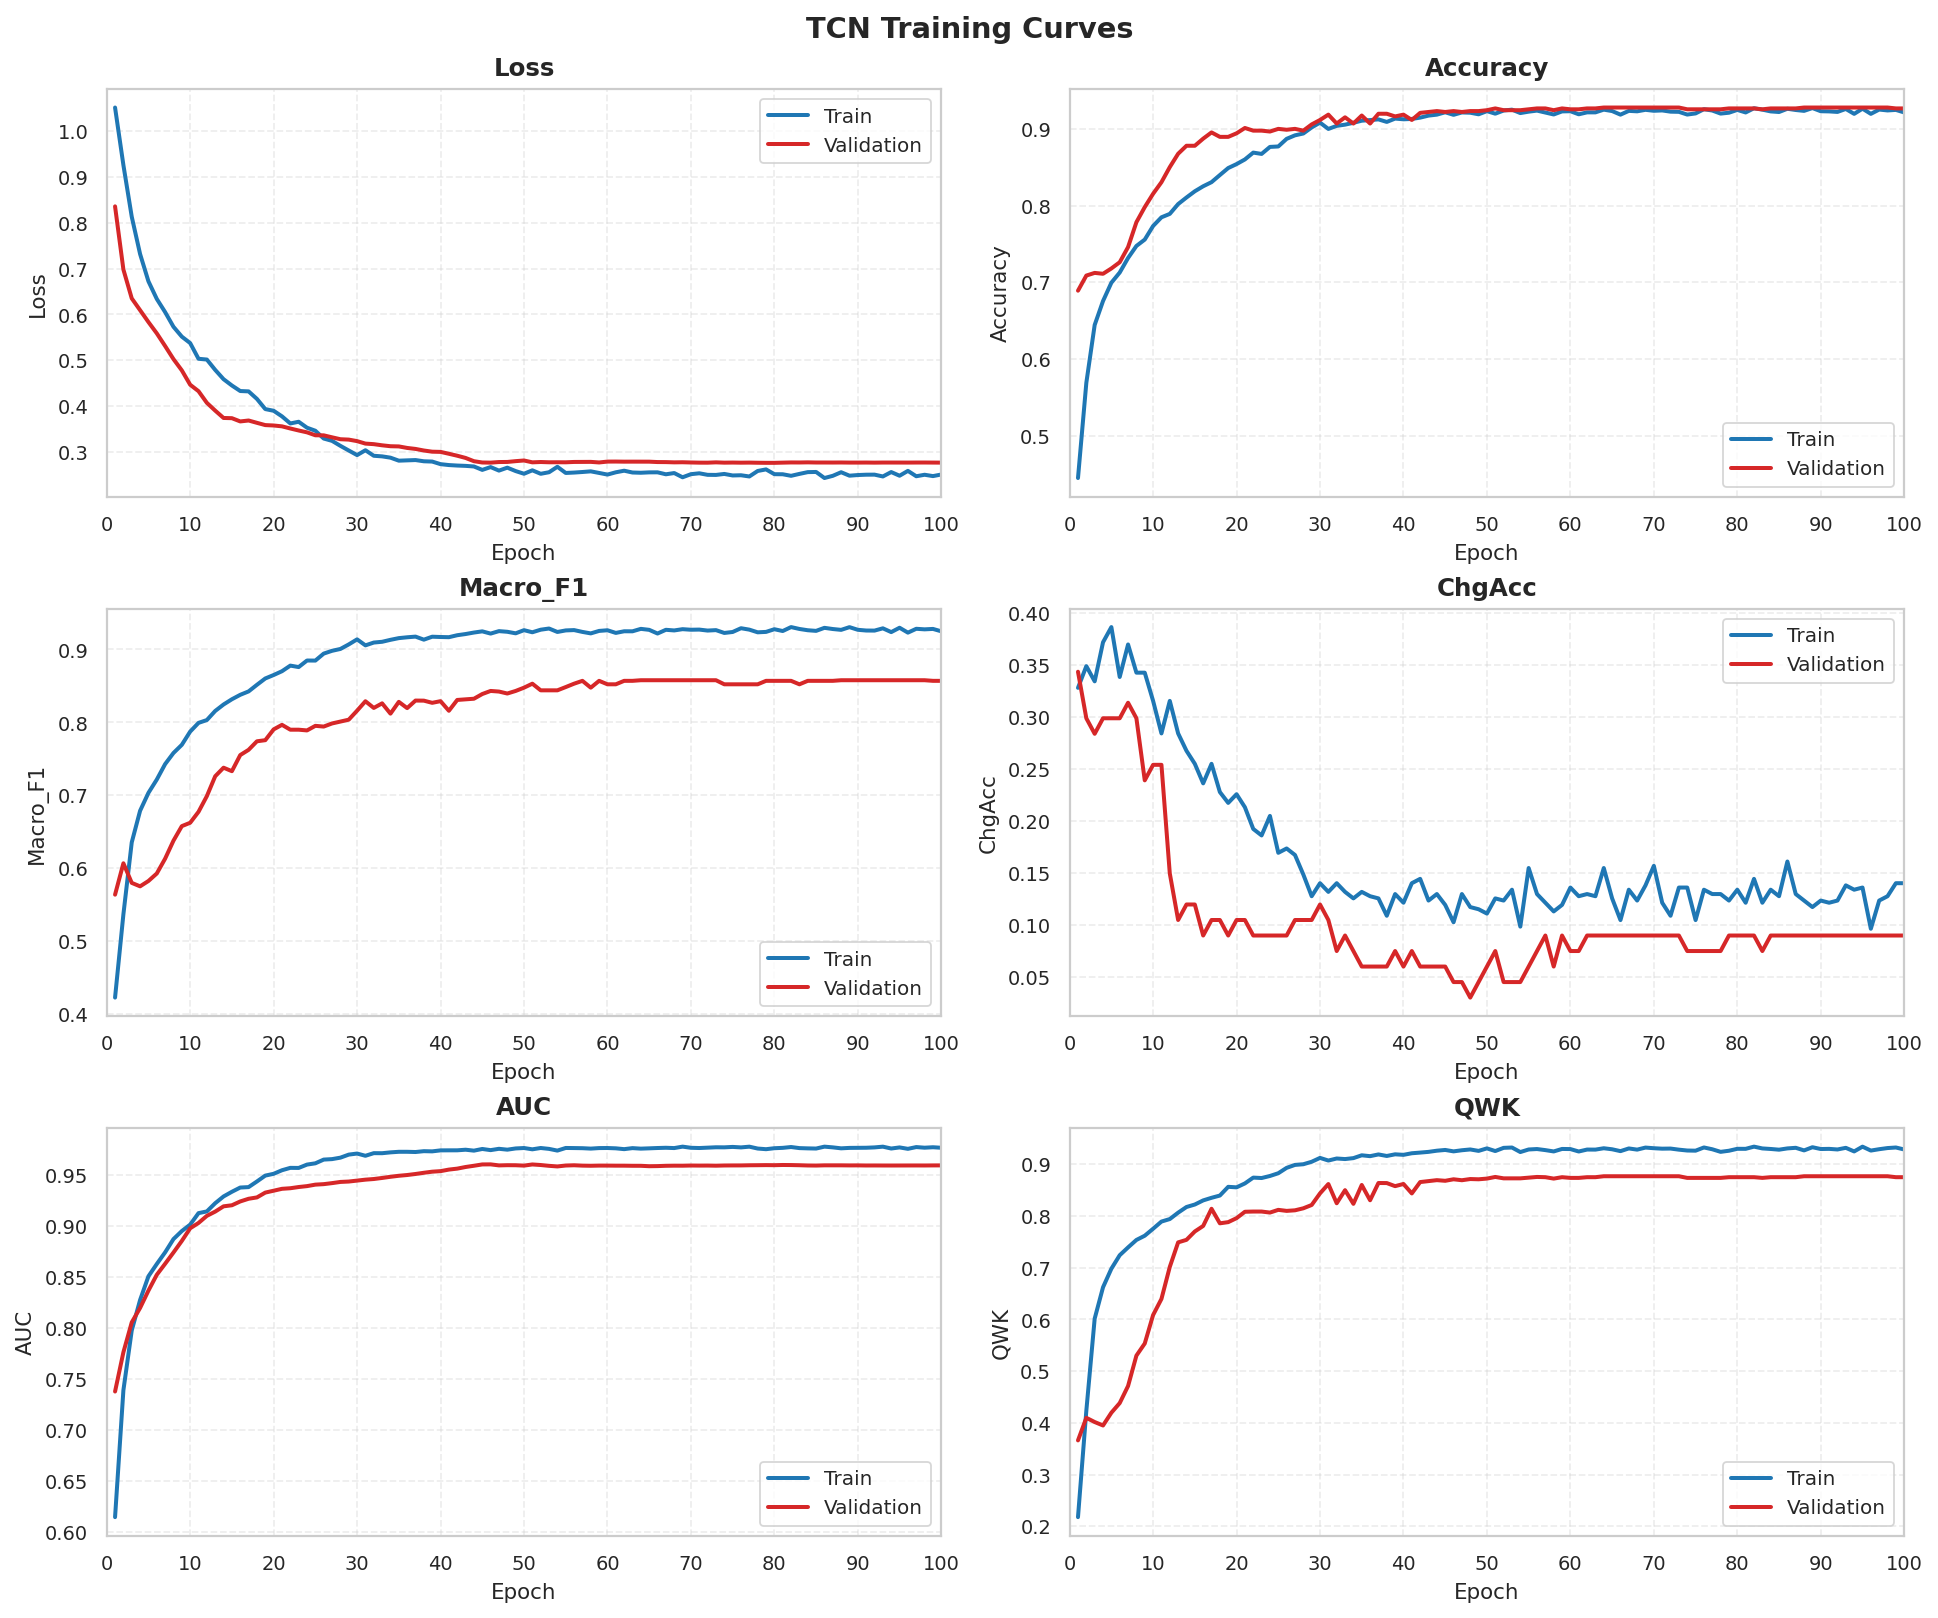

Saved: /kaggle/working/credit_rating_artifacts/tcn_training_curves.png


In [9]:
if 'history_df' not in globals():
    raise RuntimeError('Khong tim thay history_df. Hay chay lai cell huan luyen truoc.')

from matplotlib.ticker import MultipleLocator

sns.set_theme(style='whitegrid', context='paper')
metrics = ['Loss', 'Accuracy', 'Macro_F1', 'ChgAcc', 'AUC', 'QWK']
required_cols = [f'train_{m}' for m in metrics] + [f'val_{m}' for m in metrics]
missing = [c for c in required_cols if c not in history_df.columns]
if missing:
    raise RuntimeError(f'Thieu cot trong history_df: {missing}. Hay chay lai cell huan luyen.')

fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=160, constrained_layout=True)
axes = axes.ravel()
max_epoch = int(history_df['epoch'].max())

for ax, metric in zip(axes, metrics):
    ax.plot(history_df['epoch'], history_df[f'train_{metric}'], label='Train', linewidth=1.8, color='#1f77b4')
    ax.plot(history_df['epoch'], history_df[f'val_{metric}'], label='Validation', linewidth=1.8, color='#d62728')
    ax.set_title(metric, fontsize=11, fontweight='semibold')
    ax.set_xlabel('Epoch')
    ax.set_xlim(0, max_epoch)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(frameon=True, fontsize=9)

fig.suptitle('TCN Training Curves', fontsize=13, fontweight='bold')
curve_path = ARTIFACT_DIR / 'tcn_training_curves.png'
fig.savefig(curve_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', curve_path)



## Export OOF Probabilities

Lưu xác suất dự đoán (val + test) để dùng trong Fuzzy Choquet Ensemble (KB7/KB8/KB9).


In [10]:
# [AUTO] EXPORT OOF PROBABILITIES
# Lưu xác suất val và test để dùng trong Ensemble (KB7/KB8/KB9)
# Chạy cell này SAU KHI notebook đã huấn luyện xong.

import numpy as np
import torch

_MODEL_KEY = 'tcn'

# ─ Bước 1: Forward pass để khôi phục y_val/val_proba nếu thiếu ───────────────
def _extract_and_predict(model_obj, loader_obj, device_obj):
    model_obj.eval()
    all_y, all_prob = [], []
    with torch.no_grad():
        for batch in loader_obj:
            if len(batch) == 4:
                xb, lyb, sb, yb = batch
            elif len(batch) == 2:
                xb, yb = batch
                lyb, sb = None, None
            else:
                xb = batch[0]; yb = batch[-1]
                lyb = batch[1] if len(batch) > 2 else None
                sb  = batch[2] if len(batch) > 3 else None
            xb = xb.to(device_obj)
            if lyb is not None: lyb = lyb.to(device_obj)
            if sb  is not None: sb  = sb.to(device_obj)
            if lyb is not None and sb is not None:
                logits = model_obj(xb, lyb, sb)
            else:
                logits = model_obj(xb)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            all_prob.append(prob)
            all_y.append(yb.cpu().numpy() if isinstance(yb, torch.Tensor) else np.array(yb))
    return np.concatenate(all_prob), np.concatenate(all_y)

if ('y_val' not in globals() or 'y_test' not in globals()
        or 'val_proba' not in globals() or 'test_proba' not in globals()):
    _device = device if 'device' in globals() else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'[AUTO] Trích xuất dữ liệu trên thiết bị: {_device}...')
    if 'model' in globals() and 'val_loader' in globals() and 'test_loader' in globals():
        try:
            if 'val_proba' not in globals() or 'y_val' not in globals():
                val_proba, y_val = _extract_and_predict(model, val_loader, _device)
            if 'test_proba' not in globals() or 'y_test' not in globals():
                test_proba, y_test = _extract_and_predict(model, test_loader, _device)
            print('[AUTO] Trích xuất thành công val_proba, y_val, test_proba, y_test!')
        except Exception as _e:
            print(f'[AUTO] Cảnh báo: Lỗi khi tự động trích xuất: {_e}')
    else:
        print('[AUTO] Cảnh báo: Không tìm thấy model, val_loader hoặc test_loader trong globals.')

# ─ Bước 2: Guard cứng ARTIFACT_DIR + y_val + y_test ─────────────────────────
if 'ARTIFACT_DIR' not in globals():
    raise RuntimeError("ARTIFACT_DIR chưa được định nghĩa. Hãy chạy các cell setup trước.")
if 'y_val' not in globals():
    raise RuntimeError("y_val chưa được định nghĩa và không thể tự động khôi phục.")
if 'y_test' not in globals():
    raise RuntimeError("y_test chưa được định nghĩa và không thể tự động khôi phục.")
if 'val_proba' not in globals():
    raise RuntimeError("val_proba chưa được định nghĩa và không thể tự động khôi phục.")
if 'test_proba' not in globals():
    raise RuntimeError("test_proba chưa được định nghĩa và không thể tự động khôi phục.")

val_proba  = np.asarray(val_proba,  dtype=np.float32)
test_proba = np.asarray(test_proba, dtype=np.float32)

# ─ Validate shape ────────────────────────────────────────────────────────────
assert val_proba.shape[0] == len(y_val), (
    f"Shape mismatch: val_proba {val_proba.shape} vs y_val {len(y_val)}"
)
assert test_proba.shape[0] == len(y_test), (
    f"Shape mismatch: test_proba {test_proba.shape} vs y_test {len(y_test)}"
)

# ─ Lưu file ──────────────────────────────────────────────────────────────────
_save_val    = ARTIFACT_DIR / f'{_MODEL_KEY}_val_proba.npy'
_save_test   = ARTIFACT_DIR / f'{_MODEL_KEY}_test_proba.npy'
_save_y_val  = ARTIFACT_DIR / f'{_MODEL_KEY}_y_val.npy'
_save_y_test = ARTIFACT_DIR / f'{_MODEL_KEY}_y_test.npy'

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
np.save(_save_val,    val_proba)
np.save(_save_test,   test_proba)
np.save(_save_y_val,  y_val)
np.save(_save_y_test, y_test)

print(f'[OK] Saved val_proba  → {_save_val}')
print(f'[OK] Saved test_proba → {_save_test}')
print(f'[OK] Saved y_val      → {_save_y_val}')
print(f'[OK] Saved y_test     → {_save_y_test}')


# Two-tier probability calibration: OOF validation, full-validation test temperature.
_temperature_result = cross_fit_temperature_scaling(
    val_proba,
    y_val,
    test_proba,
    max_splits=5,
    seed=42,
)
calibrated_validation_probabilities = _temperature_result.validation_probabilities.astype(np.float32)
calibrated_test_probabilities = _temperature_result.test_probabilities.astype(np.float32)
np.save(ARTIFACT_DIR / "tcn_cal_val_proba.npy", calibrated_validation_probabilities)
np.save(ARTIFACT_DIR / "tcn_cal_test_proba.npy", calibrated_test_probabilities)
calibration_report = pd.DataFrame([
    {"Split": "Val", "Calibration": "raw", **probability_report(y_val, val_proba, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
    {"Split": "Val", "Calibration": "temperature_oof", **probability_report(y_val, calibrated_validation_probabilities, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
    {"Split": "Test", "Calibration": "raw", **probability_report(y_test, test_proba, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
    {"Split": "Test", "Calibration": "temperature", **probability_report(y_test, calibrated_test_probabilities, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
])
calibration_report["Temperature"] = float(_temperature_result.temperature)
calibration_report.to_csv(ARTIFACT_DIR / "tcn_two_tier_metrics.csv", index=False)
print(
    f"[OK] Temperature={_temperature_result.temperature:.6f} | "
    f"folds={_temperature_result.n_splits} | protocol={LOSS_PROTOCOL}"
)


[AUTO] Trích xuất dữ liệu trên thiết bị: cpu...
[AUTO] Trích xuất thành công val_proba, y_val, test_proba, y_test!
[OK] Saved val_proba  → /kaggle/working/credit_rating_artifacts/tcn_val_proba.npy
[OK] Saved test_proba → /kaggle/working/credit_rating_artifacts/tcn_test_proba.npy
[OK] Saved y_val      → /kaggle/working/credit_rating_artifacts/tcn_y_val.npy
[OK] Saved y_test     → /kaggle/working/credit_rating_artifacts/tcn_y_test.npy
[OK] Temperature=1.212575 | folds=5 | protocol=benchmark_ce
